# OpenCV Drone Image Analysis Exploration

This notebook is for exploring OpenCV functions with drone images captured from your VR swarm simulation.

**Target Image:** `drone_0_20251016_144256.png`

**Goals:**
- Understand different OpenCV processing techniques
- Experiment with various computer vision algorithms
- Visualize results for different approaches
- Test what works best for drone image analysis

## 0. Python and Package Checks

In [1]:
# Run this in a Jupyter cell to check
import sys
print(f"Jupyter is using Python: {sys.executable}")
print(f"Python version: {sys.version}")

# Run this in a Jupyter cell
import subprocess
result = subprocess.run([sys.executable, '-m', 'pip', 'list'], capture_output=True, text=True)
print(result.stdout)

Jupyter is using Python: c:\Program Files\Python310\python.exe
Python version: 3.10.9 (tags/v3.10.9:1dd9be6, Dec  6 2022, 20:01:21) [MSC v.1934 64 bit (AMD64)]
Package           Version
----------------- ------------
asttokens         3.0.0
colorama          0.4.6
coloredlogs       15.0.1
comm              0.2.3
contourpy         1.3.2
cycler            0.12.1
debugpy           1.8.17
decorator         5.2.1
exceptiongroup    1.3.0
executing         2.2.1
filelock          3.19.1
flatbuffers       25.9.23
fonttools         4.60.1
fsspec            2025.9.0
humanfriendly     10.0
ipykernel         7.0.1
ipython           8.37.0
jedi              0.19.2
Jinja2            3.1.6
jupyter_client    8.6.3
jupyter_core      5.9.0
kiwisolver        1.4.9
MarkupSafe        2.1.5
matplotlib        3.10.7
matplotlib-inline 0.1.7
ml_dtypes         0.5.3
mpmath            1.3.0
nest-asyncio      1.6.0
networkx          3.3
numpy             2.1.2
onnx              1.19.1
onnxruntime       1.23.1
ope

In [12]:
import segment_anything
import os
print(f"SAM installed at: {segment_anything.__file__}")
print(f"Installation method: {'Local clone' if 'git' in segment_anything.__file__ else 'Pip package'}")

SAM installed at: C:\Users\sriram\AppData\Roaming\Python\Python310\site-packages\segment_anything\__init__.py
Installation method: Pip package


## 1. Setup and Import Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Configure matplotlib for better image display
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['image.cmap'] = 'gray'

print("Libraries imported successfully!")
print(f"OpenCV version: {cv2.__version__}")

Libraries imported successfully!
OpenCV version: 4.12.0


## 2. Load and Display the Drone Image

✅ Image loaded successfully from: ../../DroneImages/drone_0_20251016_144256.png

📸 Image Information:
   Size: 640 x 480 pixels
   Channels: 3
   Data type: uint8
   File size: 114.2 KB


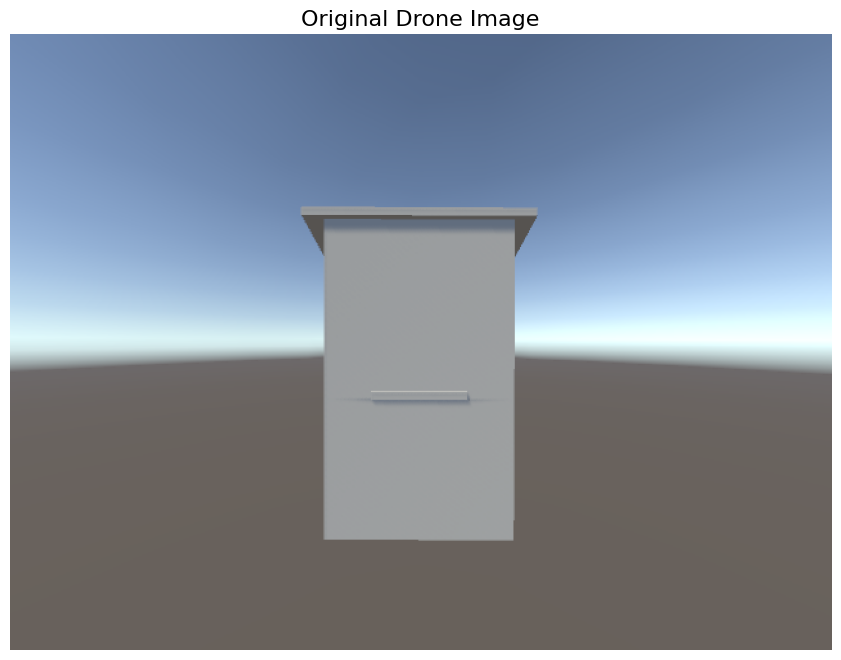

In [3]:
# Path to your drone image
# Adjust this path if your image is in a different location
image_path = "../../DroneImages/drone_0_20251016_144256.png"

# Alternative paths to try if the above doesn't work
alternative_paths = [
    "../../../DroneImages/drone_0_20251016_144256.png",
    "../../../../DroneImages/drone_0_20251016_144256.png",
    "./drone_0_20251016_144256.png",  # If you copy the image to this folder
]

# Try to load the image
image = None
actual_path = None

for path in [image_path] + alternative_paths:
    if os.path.exists(path):
        image = cv2.imread(path)
        actual_path = path
        print(f"✅ Image loaded successfully from: {path}")
        break
    else:
        print(f"❌ Image not found at: {path}")

if image is None:
    print("\n🚨 Could not find the image file!")
    print("Please:")
    print("1. Check if the image exists in the DroneImages folder")
    print("2. Update the image_path variable above with the correct path")
    print("3. Or copy the image to this notebook's folder")
else:
    # Convert BGR to RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Display basic image info
    height, width, channels = image.shape
    print(f"\n📸 Image Information:")
    print(f"   Size: {width} x {height} pixels")
    print(f"   Channels: {channels}")
    print(f"   Data type: {image.dtype}")
    print(f"   File size: {os.path.getsize(actual_path) / 1024:.1f} KB")
    
    # Display the original image
    plt.figure(figsize=(12, 8))
    plt.imshow(image_rgb)
    plt.title("Original Drone Image", fontsize=16)
    plt.axis('off')
    plt.show()

# 3. SegmentAnything

In [16]:
#load library and model
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry

# larger model
# sam = sam_model_registry["vit_h"](checkpoint="../../segmentAnything/sam_vit_h_4b8939.pth")
# mask_generator = SamAutomaticMaskGenerator(sam)

# use smaller model instead for now sam_vit_b_01ec64
sam = sam_model_registry["vit_b"](checkpoint="../../segmentAnything/sam_vit_b_01ec64.pth")
mask_generator = SamAutomaticMaskGenerator(sam)
# Generate all possible masks/segments in the image
masks = mask_generator.generate(image_rgb)


In [17]:
# #TEST

# #model in sam_vit_h_4b8939.pth in Assets/segmentAnything
# #image loaded from ../../DroneImages/drone_0_20251016_144256.png

# from segment_anything import SamPredictor, sam_model_registry
# sam = sam_model_registry["vit_h"](checkpoint="../../segmentAnything/sam_vit_h_4b8939.pth")
# predictor = SamPredictor(sam)
# predictor.set_image(image_rgb)
# # masks, _, _ = predictor.predict(<input_prompts>)

In [18]:
# Generate all possible masks/segments in the image
print("🔍 Generating all possible segments... (this may take a moment)")

print(f"✅ Found {len(masks)} potential segments!")

# Display basic info about the masks
for i, mask_info in enumerate(masks[:5]):  # Show info for first 5 masks
    area = mask_info['area']
    stability_score = mask_info['stability_score']
    print(f"Segment {i}: Area={area} pixels, Stability={stability_score:.3f}")
    
print(f"... and {len(masks)-5} more segments")

🔍 Generating all possible segments... (this may take a moment)
✅ Found 6 potential segments!
Segment 0: Area=142947 pixels, Stability=0.976
Segment 1: Area=38905 pixels, Stability=0.984
Segment 2: Area=606 pixels, Stability=0.974
Segment 3: Area=2097 pixels, Stability=0.959
Segment 4: Area=252 pixels, Stability=0.969
... and 1 more segments


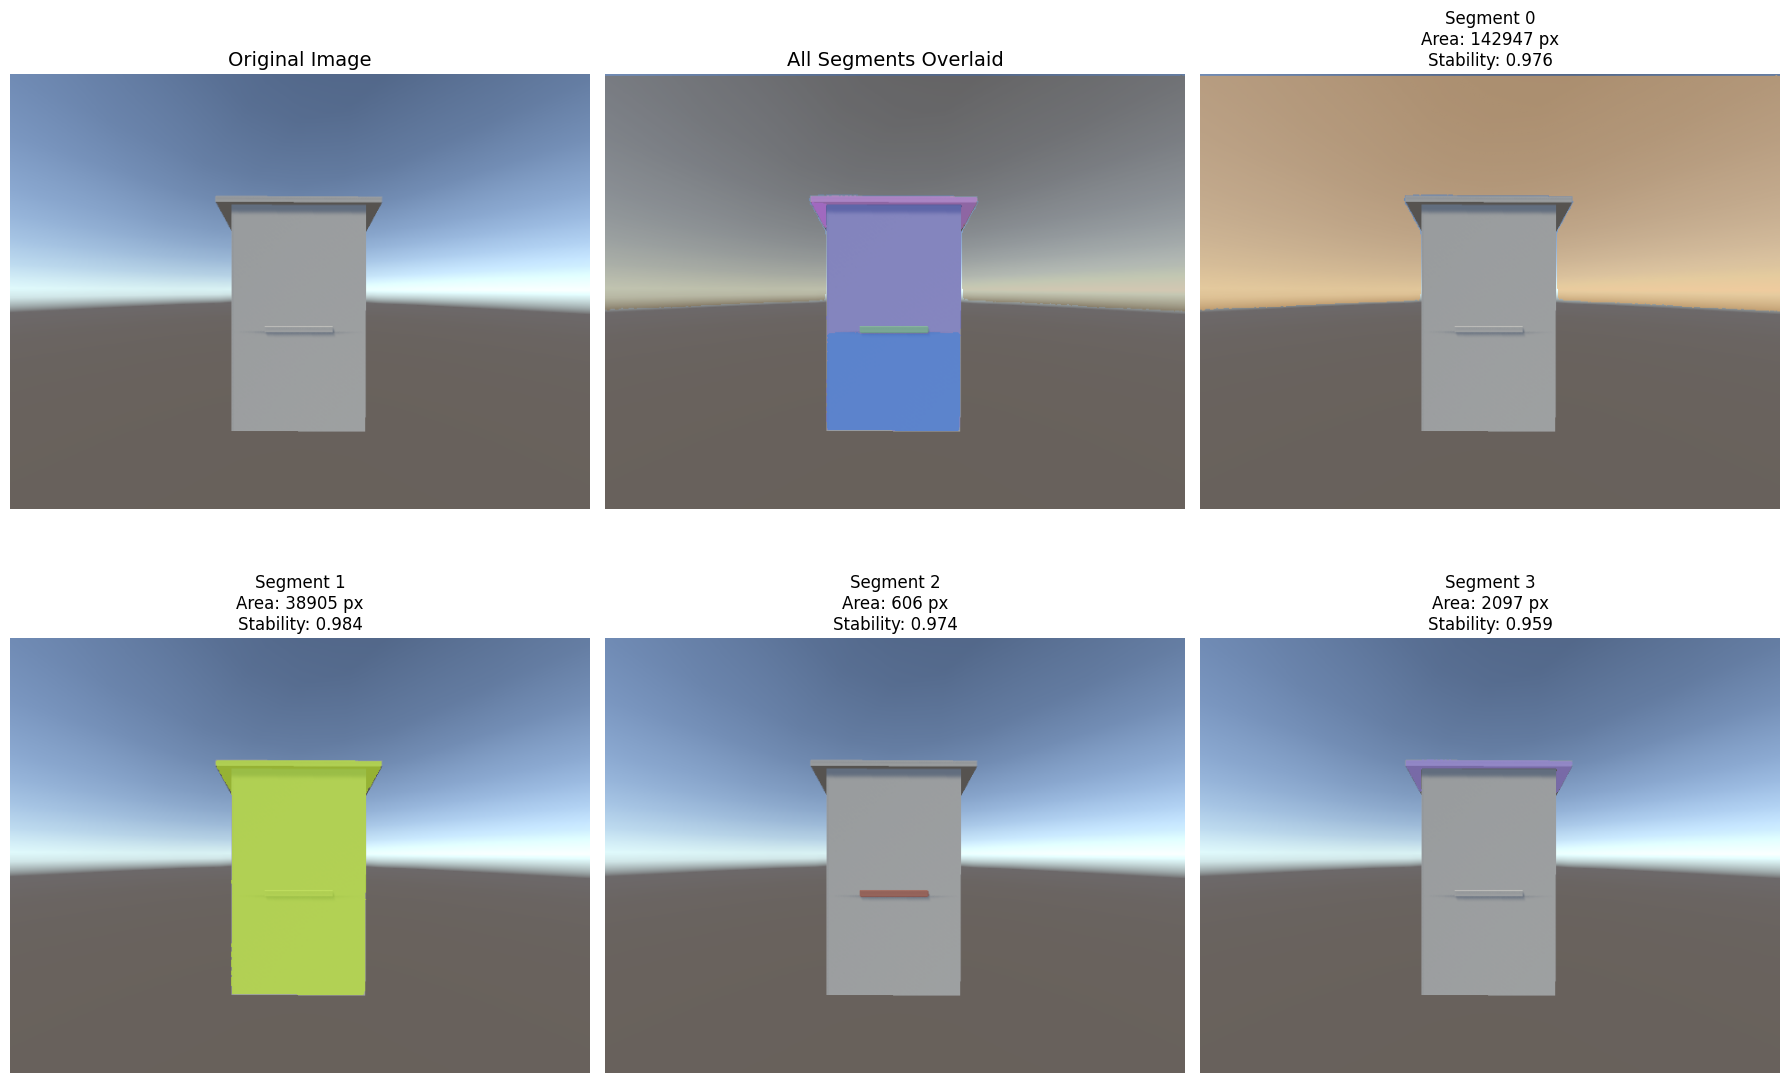


🔍 Detailed Segment Information:

Segment 0:
  Area: 142,947 pixels (46.5% of image)
  Stability Score: 0.976
  Bounding Box: x=0.0, y=1.0, w=639.0, h=260.0

Segment 1:
  Area: 38,905 pixels (12.7% of image)
  Stability Score: 0.984
  Bounding Box: x=227.0, y=135.0, w=182.0, h=258.0

Segment 2:
  Area: 606 pixels (0.2% of image)
  Stability Score: 0.974
  Bounding Box: x=281.0, y=278.0, w=76.0, h=7.0

Segment 3:
  Area: 2,097 pixels (0.7% of image)
  Stability Score: 0.959
  Bounding Box: x=227.0, y=134.0, w=183.0, h=36.0

Segment 4:
  Area: 252 pixels (0.1% of image)
  Stability Score: 0.969
  Bounding Box: x=228.0, y=141.0, w=15.0, h=28.0

Segment 5:
  Area: 15,738 pixels (5.1% of image)
  Stability Score: 0.972
  Bounding Box: x=245.0, y=285.0, w=146.0, h=108.0


In [19]:
# Add this as a new cell in your notebook
## 4. Visualize All Segments

def show_anns(anns, ax):
    """Helper function to display annotations"""
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    
    for ann in sorted_anns:
        m = ann['segmentation']
        img = np.ones((m.shape[0], m.shape[1], 3))
        color_mask = np.random.random((1, 3)).tolist()[0]
        for i in range(3):
            img[:,:,i] = color_mask[i]
        ax.imshow(np.dstack((img, m*0.35)))

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Original image
axes[0].imshow(image_rgb)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

# All segments overlaid
axes[1].imshow(image_rgb)
show_anns(masks, axes[1])
axes[1].set_title("All Segments Overlaid", fontsize=14)
axes[1].axis('off')

# Individual segments (first 4)
for i in range(min(4, len(masks))):
    ax = axes[i + 2]
    
    # Show original image with single segment highlighted
    ax.imshow(image_rgb)
    
    # Create colored mask for this segment
    mask = masks[i]['segmentation']
    colored_mask = np.zeros((mask.shape[0], mask.shape[1], 4))
    colored_mask[:, :, :3] = np.random.random(3)  # Random color
    colored_mask[:, :, 3] = mask * 0.6  # Alpha channel
    
    ax.imshow(colored_mask)
    ax.set_title(f"Segment {i}\nArea: {masks[i]['area']} px\nStability: {masks[i]['stability_score']:.3f}", 
                fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Print detailed information about each segment
print("\n🔍 Detailed Segment Information:")
for i, mask_info in enumerate(masks):
    area = mask_info['area']
    stability = mask_info['stability_score']
    bbox = mask_info['bbox']  # [x, y, width, height]
    
    print(f"\nSegment {i}:")
    print(f"  Area: {area:,} pixels ({area/(height*width)*100:.1f}% of image)")
    print(f"  Stability Score: {stability:.3f}")
    print(f"  Bounding Box: x={bbox[0]}, y={bbox[1]}, w={bbox[2]}, h={bbox[3]}")

🎯 Image center: (320, 240)
✅ Segment 1 contains center point

🏆 Best center segment: #1
   Area: 38,905 pixels
   Stability: 0.984


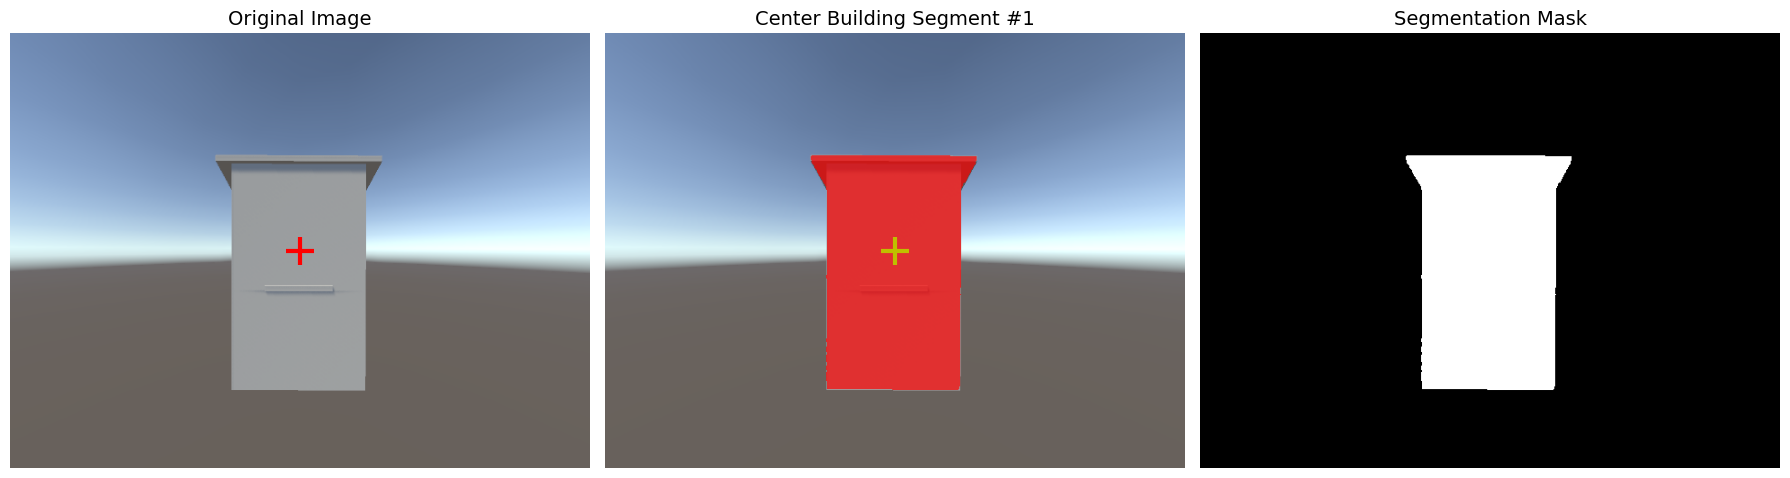

In [20]:
# Add this as another new cell
## 5. Find Center Building Segment

# Calculate image center
center_x = width // 2
center_y = height // 2
print(f"🎯 Image center: ({center_x}, {center_y})")

# Function to check if a point is inside a mask
def point_in_mask(mask, x, y):
    """Check if point (x,y) is inside the segmentation mask"""
    if 0 <= y < mask.shape[0] and 0 <= x < mask.shape[1]:
        return mask[y, x]
    return False

# Find segments that contain the center point
center_segments = []
for i, mask_info in enumerate(masks):
    mask = mask_info['segmentation']
    if point_in_mask(mask, center_x, center_y):
        center_segments.append((i, mask_info))
        print(f"✅ Segment {i} contains center point")

if center_segments:
    # If multiple segments contain center, choose the one with best balance of area and stability
    best_segment = max(center_segments, 
                      key=lambda x: x[1]['stability_score'] * min(x[1]['area']/1000, 100))
    
    segment_idx, segment_info = best_segment
    print(f"\n🏆 Best center segment: #{segment_idx}")
    print(f"   Area: {segment_info['area']:,} pixels")
    print(f"   Stability: {segment_info['stability_score']:.3f}")
    
    # Visualize the center building segment
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original image
    axes[0].imshow(image_rgb)
    axes[0].set_title("Original Image", fontsize=14)
    axes[0].plot(center_x, center_y, 'r+', markersize=20, markeredgewidth=3)
    axes[0].axis('off')
    
    # Center segment highlighted
    axes[1].imshow(image_rgb)
    center_mask = segment_info['segmentation']
    colored_mask = np.zeros((center_mask.shape[0], center_mask.shape[1], 4))
    colored_mask[:, :, :3] = [1, 0, 0]  # Red color
    colored_mask[:, :, 3] = center_mask * 0.7
    axes[1].imshow(colored_mask)
    axes[1].plot(center_x, center_y, 'y+', markersize=20, markeredgewidth=3)
    axes[1].set_title(f"Center Building Segment #{segment_idx}", fontsize=14)
    axes[1].axis('off')
    
    # Mask only (binary)
    axes[2].imshow(center_mask, cmap='gray')
    axes[2].set_title("Segmentation Mask", fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ No segments found that contain the center point")
    print("The building might be segmented into multiple parts or SAM might need different parameters")
    
    # Show all segments with center point marked
    plt.figure(figsize=(12, 8))
    plt.imshow(image_rgb)
    show_anns(masks, plt.gca())
    plt.plot(center_x, center_y, 'r+', markersize=20, markeredgewidth=3)
    plt.title("All Segments with Center Point Marked", fontsize=16)
    plt.axis('off')
    plt.show()

In [21]:
# Add this cell to check your setup
## Speed Optimization Check

import torch
print(f"🔧 Performance Information:")
print(f"   PyTorch version: {torch.__version__}")
print(f"   CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"   Current device: {torch.cuda.current_device()}")
else:
    print("   Running on CPU (slower)")

print(f"\n📸 Image size: {width} x {height} = {width*height:,} pixels")
print(f"   Larger images take longer to process")

# Suggestions for faster processing
print(f"\n⚡ Speed optimization suggestions:")
print(f"   1. Use smaller model: 'vit_b' or 'vit_l' instead of 'vit_h'")
print(f"   2. Resize image to smaller resolution for testing")
print(f"   3. Use GPU if available")
print(f"   4. Adjust SAM parameters for fewer segments")

🔧 Performance Information:
   PyTorch version: 2.9.0+cu126
   CUDA available: True
   CUDA device: NVIDIA GeForce RTX 4090
   Current device: 0

📸 Image size: 640 x 480 = 307,200 pixels
   Larger images take longer to process

⚡ Speed optimization suggestions:
   1. Use smaller model: 'vit_b' or 'vit_l' instead of 'vit_h'
   2. Resize image to smaller resolution for testing
   3. Use GPU if available
   4. Adjust SAM parameters for fewer segments


## 4. SegmentAnything using CUDA

In [ ]:

import torch
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import time
from pathlib import Path
import os

In [8]:
# Replace your SAM initialization cell with this to force GPU usage
## 3. SegmentAnything - GPU Accelerated


# Force CUDA device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

# Load model on GPU
sam = sam_model_registry["vit_b"](checkpoint="../../segmentAnything/sam_vit_b_01ec64.pth")
sam.to(device)  # Move model to GPU
print(f"✅ SAM model loaded on {device}")

# Create mask generator with GPU acceleration
mask_generator = SamAutomaticMaskGenerator(
    sam,
    # Optional: Tune these parameters for better performance/quality
    points_per_side=32,           # Reduce from default 32 for speed
    pred_iou_thresh=0.88,         # Higher = fewer, better quality masks
    stability_score_thresh=0.95,  # Higher = more stable masks
    crop_n_layers=1,              # Reduce for speed
    crop_n_points_downscale_factor=2,
    min_mask_region_area=1000,    # Minimum area (pixels) for a mask
)

print("🎯 Generating all possible segments... (GPU accelerated)")
import time
start_time = time.time()

image_path = "../../DroneImages/drone_0_20251016_144256.png"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#height and width
height, width, _ = image.shape
print(f"📸 Image size: {width} x {height}|| {width*height:,} pixels")

# Generate masks
masks = mask_generator.generate(image_rgb)

end_time = time.time()
print(f"⏱️  Segmentation completed in {end_time - start_time:.2f} seconds")
print(f"✅ Found {len(masks)} potential segments!")


🚀 Using device: cuda
✅ SAM model loaded on cuda
🎯 Generating all possible segments... (GPU accelerated)
📸 Image size: 640 x 480|| 307,200 pixels
⏱️  Segmentation completed in 2.34 seconds
✅ Found 7 potential segments!


🎯 Image center: (320, 240)
📏 Minimum building area: 7,500 pixels
✅ Segment 1 contains center point AND meets area requirement
   Area: 38,904 pixels (12.7% of image)

🔍 Found 1 candidate building segments

🏆 Best center building segment: #1
   Area: 38,904 pixels (12.7% of image)
   Stability: 0.984
   Bounding Box: [227.0, 135.0, 182.0, 258.0]
   Building centroid: (318, 261)
   Offset from image center: (-2, 21)


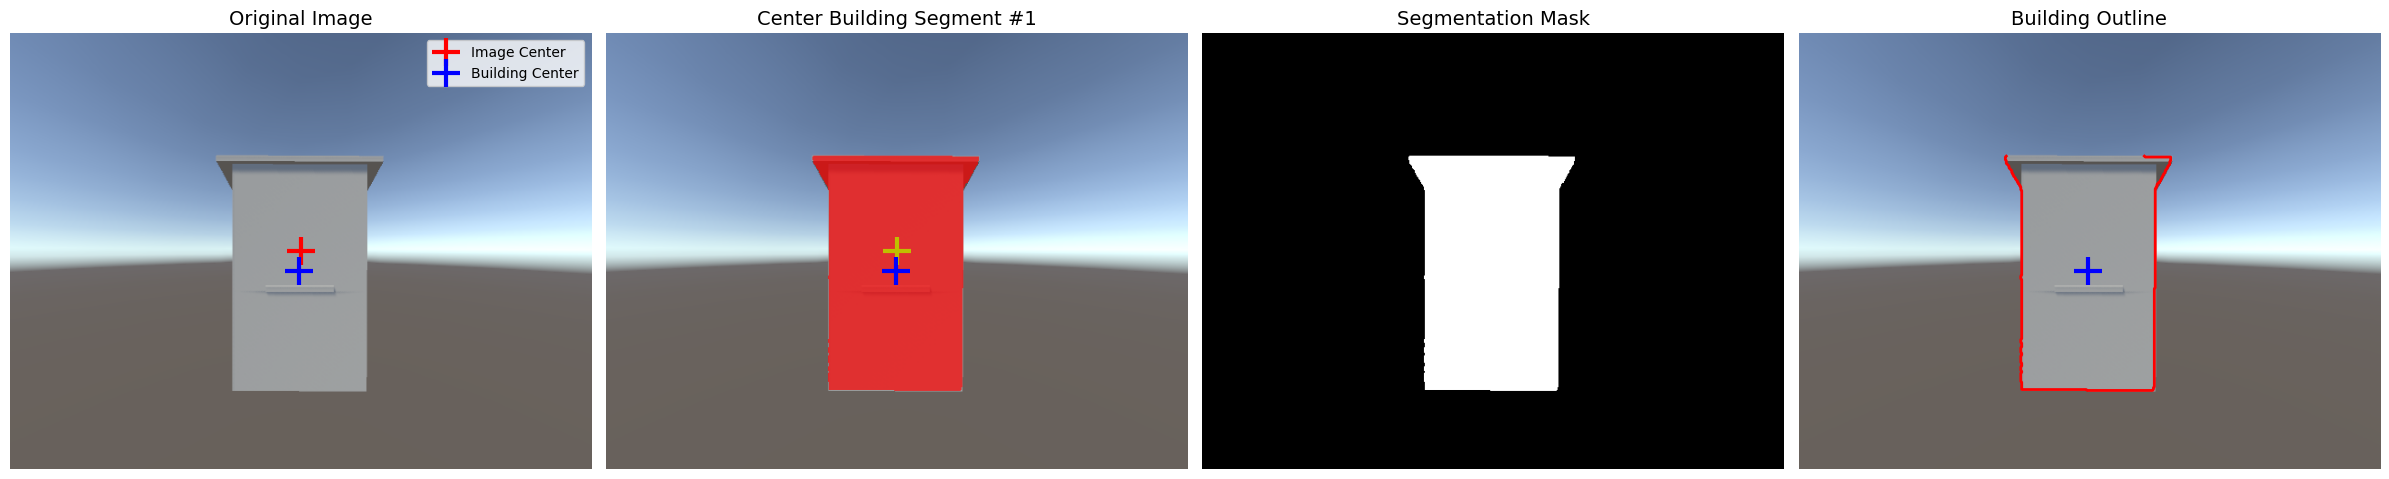


💾 Building info stored for NBV processing:
   Building detected: 38,904 pixels
   Center offset: (-2, 21)


In [ ]:
# Replace your center building detection cell with this
## 5. Find Center Building Segment (with minimum area constraint)

# Calculate image center
center_x = width // 2
center_y = height // 2
print(f"🎯 Image center: ({center_x}, {center_y})")

# Minimum area constraint
MIN_BUILDING_AREA = 7500  # pixels
print(f"📏 Minimum building area: {MIN_BUILDING_AREA:,} pixels")

# Function to check if a point is inside a mask
def point_in_mask(mask, x, y):
    """Check if point (x,y) is inside the segmentation mask"""
    if 0 <= y < mask.shape[0] and 0 <= x < mask.shape[1]:
        return mask[y, x]
    return False

# Find segments that contain the center point AND meet area requirement
center_segments = []
for i, mask_info in enumerate(masks):
    mask = mask_info['segmentation']
    area = mask_info['area']
    
    # Check both center point and minimum area
    if point_in_mask(mask, center_x, center_y) and area >= MIN_BUILDING_AREA:
        center_segments.append((i, mask_info))
        print(f"✅ Segment {i} contains center point AND meets area requirement")
        print(f"   Area: {area:,} pixels ({area/(height*width)*100:.1f}% of image)")
    elif point_in_mask(mask, center_x, center_y):
        print(f"⚠️  Segment {i} contains center but too small: {area:,} pixels")

print(f"\n🔍 Found {len(center_segments)} candidate building segments")

if center_segments:
    # Choose the best segment: balance of area, stability, and reasonable size
    best_segment = max(center_segments, 
                      key=lambda x: x[1]['stability_score'] * min(x[1]['area']/10000, 10))
    
    segment_idx, segment_info = best_segment
    print(f"\n🏆 Best center building segment: #{segment_idx}")
    print(f"   Area: {segment_info['area']:,} pixels ({segment_info['area']/(height*width)*100:.1f}% of image)")
    print(f"   Stability: {segment_info['stability_score']:.3f}")
    print(f"   Bounding Box: {segment_info['bbox']}")
    
    # Calculate building center from the mask
    center_mask = segment_info['segmentation']
    building_pixels = np.where(center_mask)
    building_center_y = int(np.mean(building_pixels[0]))
    building_center_x = int(np.mean(building_pixels[1]))
    
    print(f"   Building centroid: ({building_center_x}, {building_center_y})")
    print(f"   Offset from image center: ({building_center_x - center_x}, {building_center_y - center_y})")
    
    # Visualize the center building segment
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    # Original image with center marked
    axes[0].imshow(image_rgb)
    axes[0].set_title("Original Image", fontsize=14)
    axes[0].plot(center_x, center_y, 'r+', markersize=20, markeredgewidth=3, label='Image Center')
    axes[0].plot(building_center_x, building_center_y, 'b+', markersize=20, markeredgewidth=3, label='Building Center')
    axes[0].legend()
    axes[0].axis('off')
    
    # Center segment highlighted
    axes[1].imshow(image_rgb)
    colored_mask = np.zeros((center_mask.shape[0], center_mask.shape[1], 4))
    colored_mask[:, :, :3] = [1, 0, 0]  # Red color
    colored_mask[:, :, 3] = center_mask * 0.7
    axes[1].imshow(colored_mask)
    axes[1].plot(center_x, center_y, 'y+', markersize=20, markeredgewidth=3)
    axes[1].plot(building_center_x, building_center_y, 'b+', markersize=20, markeredgewidth=3)
    axes[1].set_title(f"Center Building Segment #{segment_idx}", fontsize=14)
    axes[1].axis('off')
    
    # Mask only (binary)
    axes[2].imshow(center_mask, cmap='gray')
    axes[2].set_title("Segmentation Mask", fontsize=14)
    axes[2].axis('off')
    
    # Building outline on original
    axes[3].imshow(image_rgb)
    # Create outline from mask
    contours, _ = cv2.findContours(center_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        # Convert contour points for matplotlib
        contour_points = contour.reshape(-1, 2)
        axes[3].plot(contour_points[:, 0], contour_points[:, 1], 'r-', linewidth=2)
    axes[3].plot(building_center_x, building_center_y, 'b+', markersize=20, markeredgewidth=3)
    axes[3].set_title("Building Outline", fontsize=14)
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Store the building info for later use
    building_info = {
        'segment_idx': segment_idx,
        'mask': center_mask,
        'area': segment_info['area'],
        'stability': segment_info['stability_score'],
        'bbox': segment_info['bbox'],
        'center': (building_center_x, building_center_y),
        'offset_from_image_center': (building_center_x - center_x, building_center_y - center_y)
    }
    
    print(f"   Building detected: {building_info['area']:,} pixels")
    print(f"   Center offset: {building_info['offset_from_image_center']}")
    
else:
    print("❌ No segments found that contain the center point AND meet minimum area requirement")
    print(f"   Try reducing MIN_BUILDING_AREA below {MIN_BUILDING_AREA}")
    
    # Show all segments with center point and area info
    plt.figure(figsize=(12, 8))
    plt.imshow(image_rgb)
    show_anns(masks, plt.gca())
    plt.plot(center_x, center_y, 'r+', markersize=20, markeredgewidth=3)
    plt.title("All Segments with Center Point Marked", fontsize=16)
    plt.axis('off')
    plt.show()
    
    # Print info about segments near center
    print(f"\nSegments containing center point (regardless of size):")
    for i, mask_info in enumerate(masks):
        mask = mask_info['segmentation']
        if point_in_mask(mask, center_x, center_y):
            area = mask_info['area']
            print(f"  Segment {i}: {area:,} pixels {'✅' if area >= MIN_BUILDING_AREA else '❌ too small'}")

### 4.2 Extend to process all images in DroneImages Folder

🚀 Starting batch processing of all drone images...
🔍 Found 30 images to process
📂 Processing images from: ../../DroneImages
🚀 Using GPU acceleration: cuda
📏 Minimum building area: 7,500 pixels
------------------------------------------------------------

📸 Processing image 1/30: drone_0_20251016_144224.png
✅ Building detected!
   Area: 23,824 pixels (7.8% of image)
   Center offset: (-9, 68)
   Processing time: 2.63 seconds


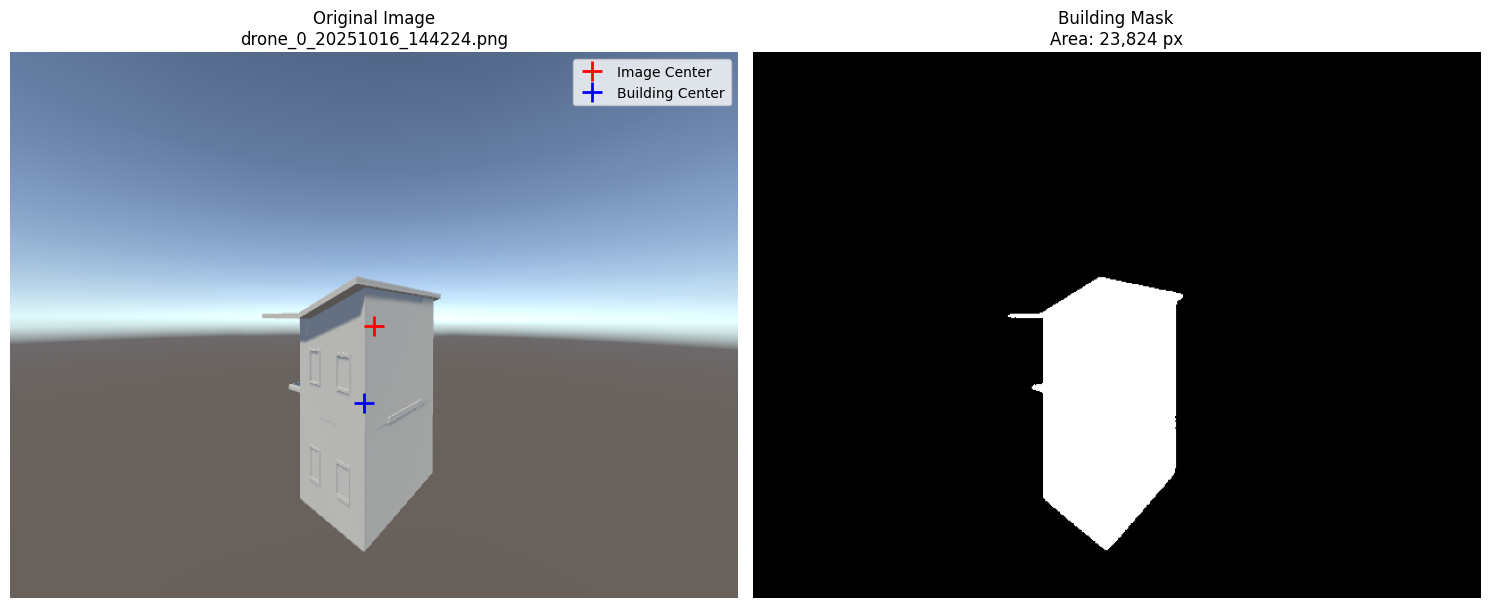


📸 Processing image 2/30: drone_0_20251016_144226.png
✅ Building detected!
   Area: 26,930 pixels (8.8% of image)
   Center offset: (-8, 24)
   Processing time: 2.30 seconds


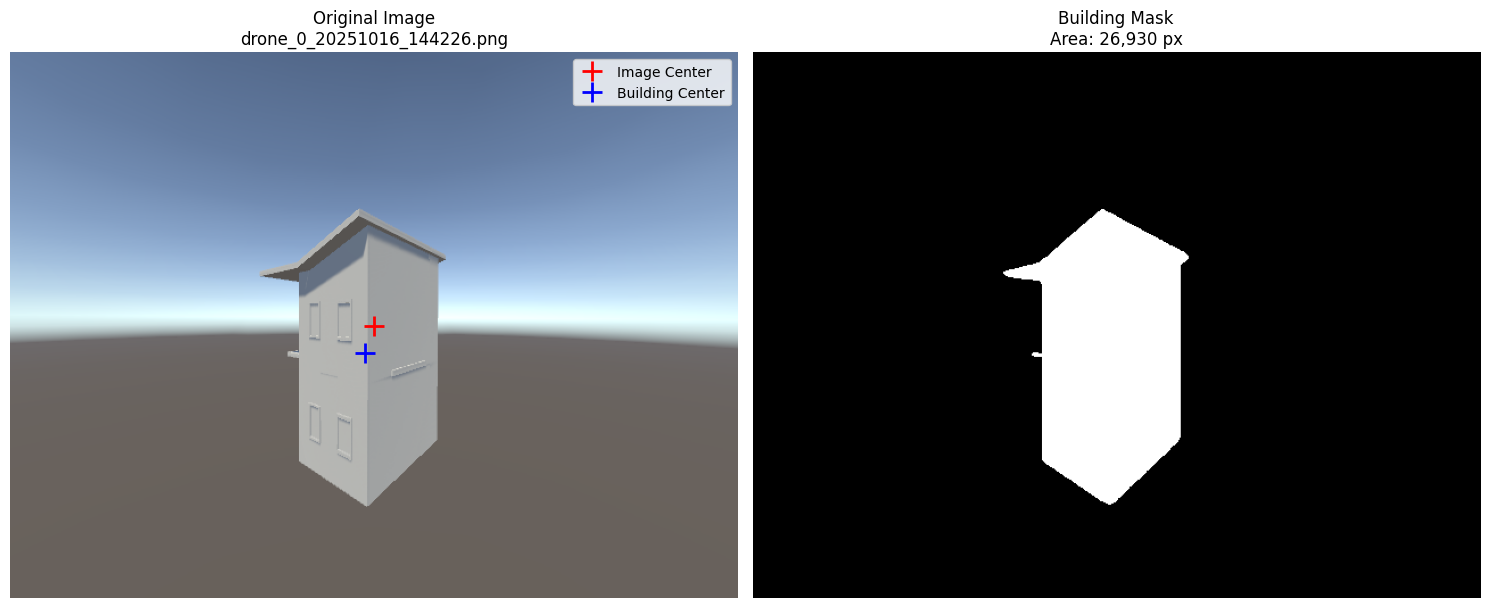


📸 Processing image 3/30: drone_0_20251016_144228.png
✅ Building detected!
   Area: 34,594 pixels (11.3% of image)
   Center offset: (-10, -1)
   Processing time: 2.31 seconds


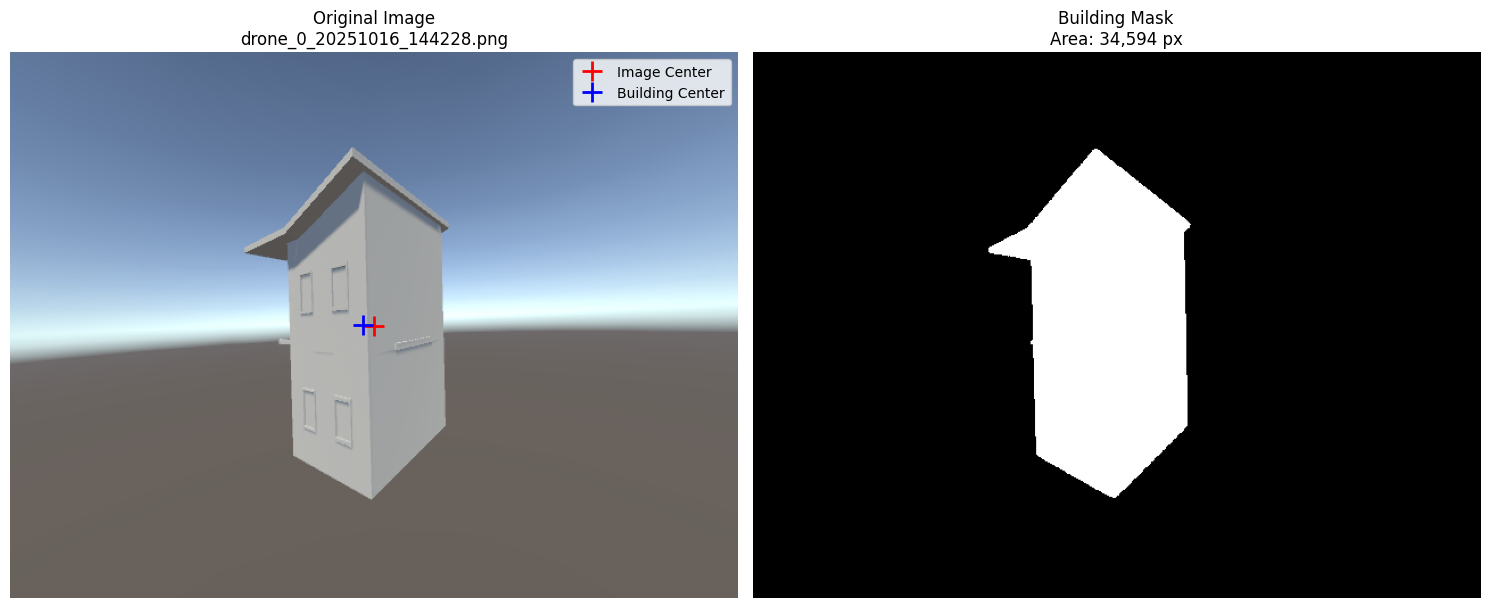


📸 Processing image 4/30: drone_0_20251016_144246.png
✅ Building detected!
   Area: 39,352 pixels (12.8% of image)
   Center offset: (-9, 25)
   Processing time: 2.23 seconds


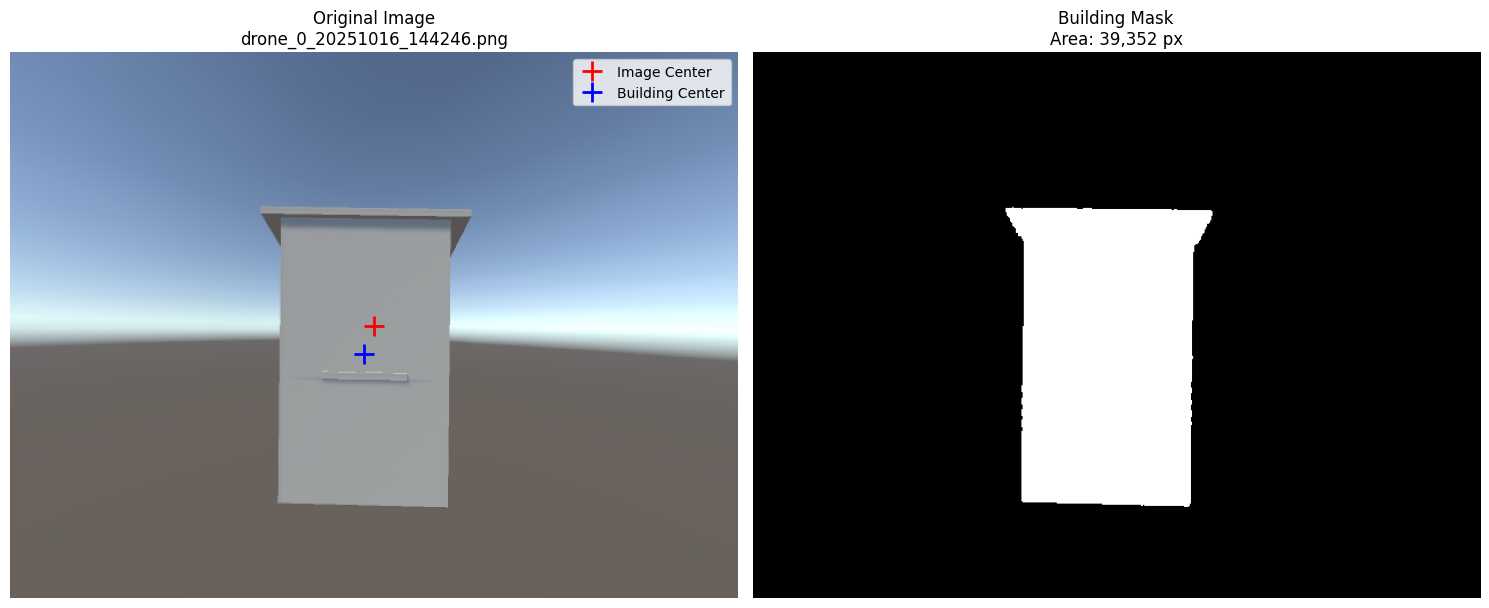


📸 Processing image 5/30: drone_0_20251016_144252.png
✅ Building detected!
   Area: 44,156 pixels (14.4% of image)
   Center offset: (1, 30)
   Processing time: 2.26 seconds


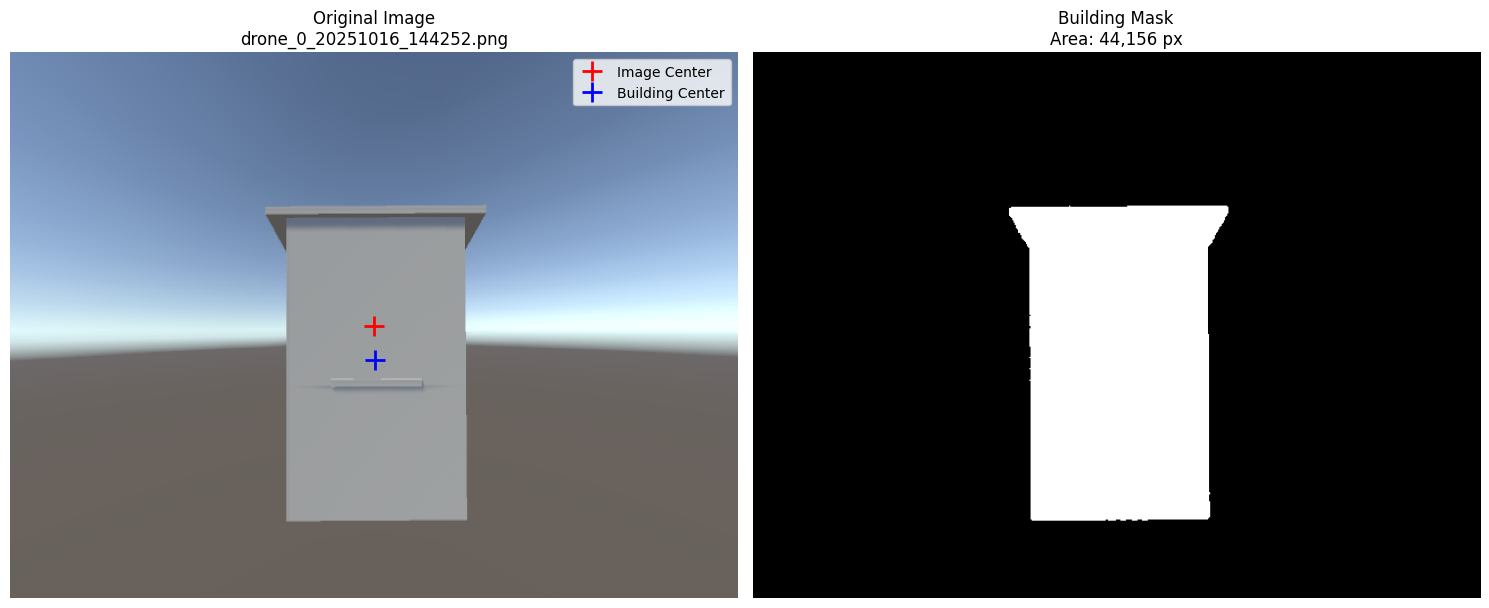


📸 Processing image 6/30: drone_1_20251016_144226.png
✅ Building detected!
   Area: 66,750 pixels (21.7% of image)
   Center offset: (-16, 37)
   Processing time: 2.32 seconds


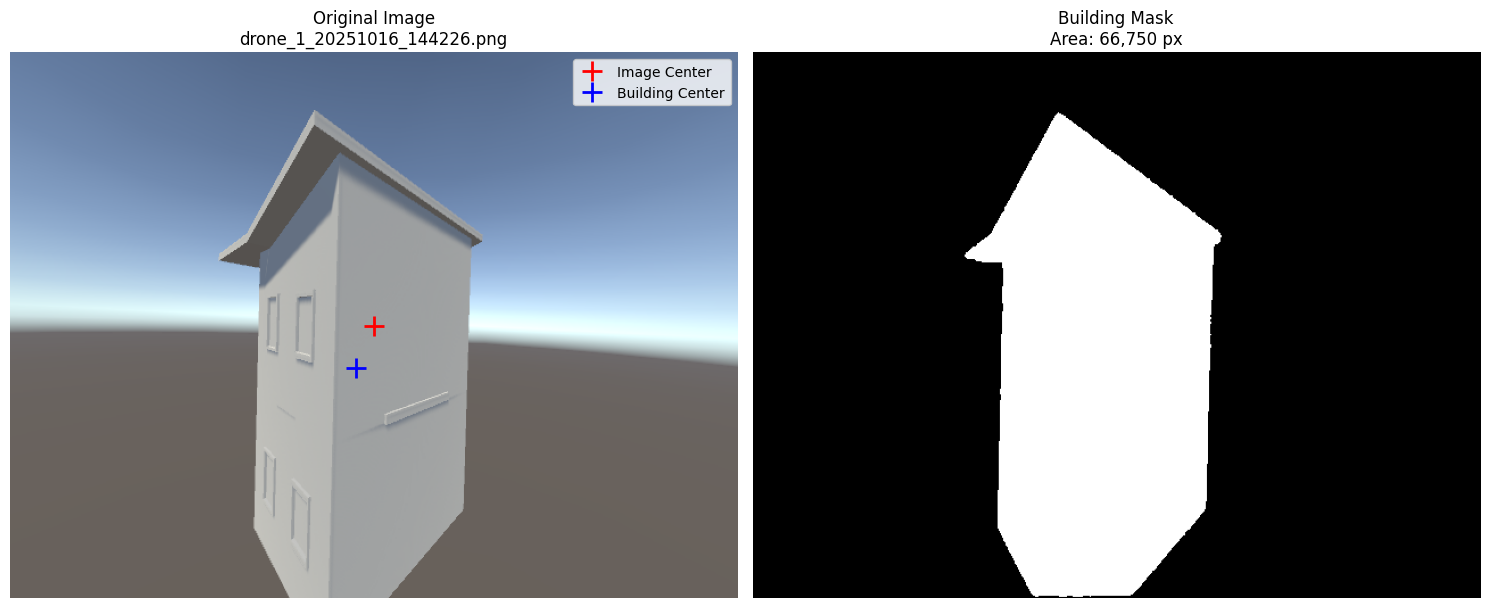


📸 Processing image 7/30: drone_1_20251016_144244.png
✅ Building detected!
   Area: 32,628 pixels (10.6% of image)
   Center offset: (-16, 29)
   Processing time: 2.28 seconds


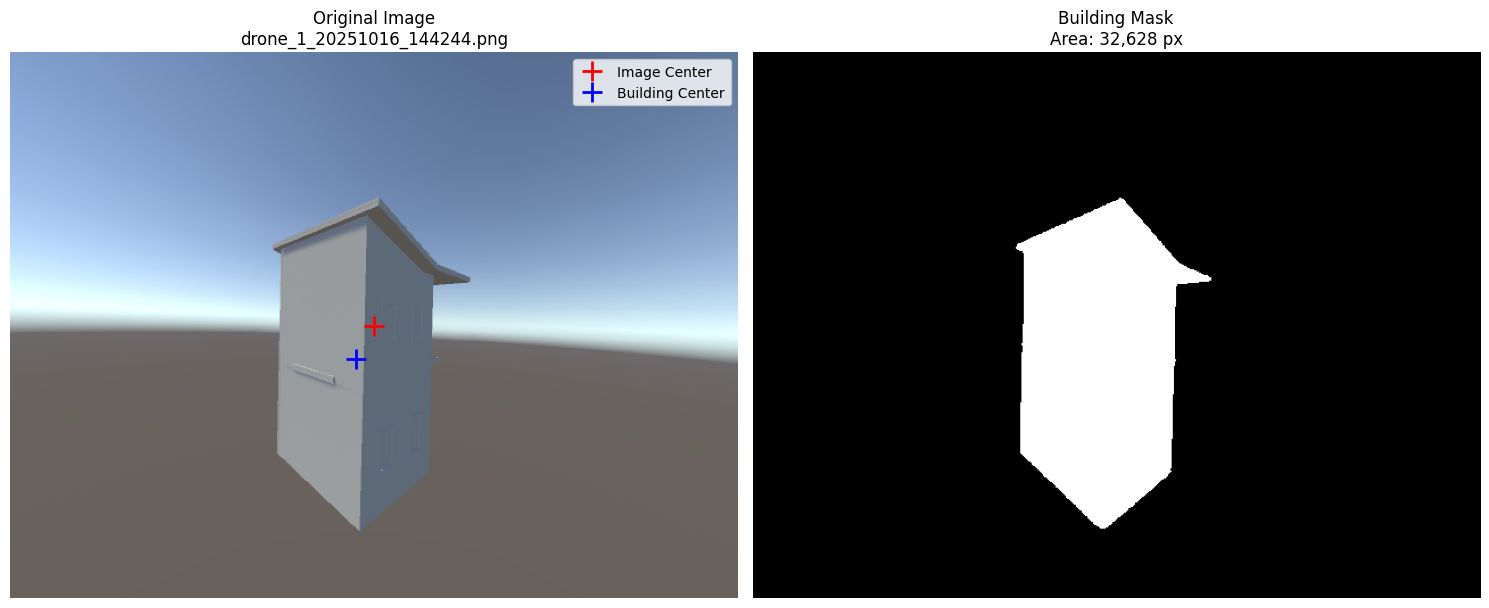


📸 Processing image 8/30: drone_1_20251016_144248.png
✅ Building detected!
   Area: 40,974 pixels (13.3% of image)
   Center offset: (13, 27)
   Processing time: 2.29 seconds


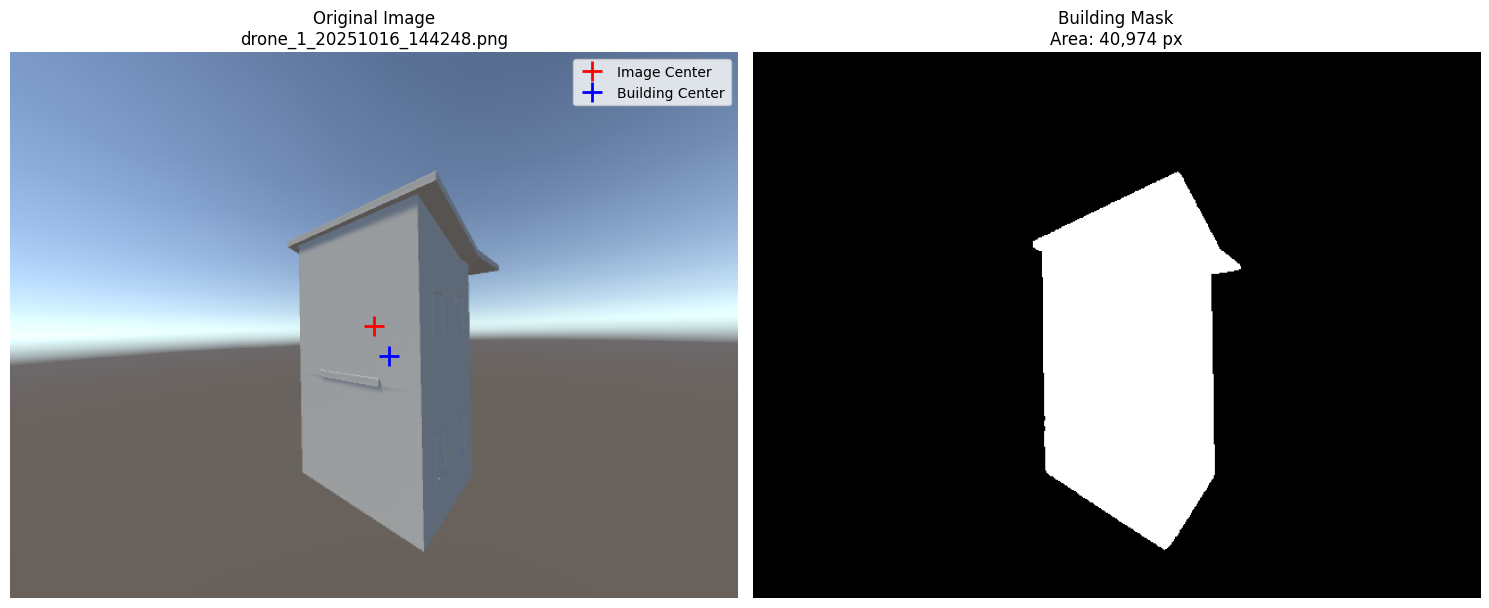


📸 Processing image 9/30: drone_1_20251016_144254.png
✅ Building detected!
   Area: 35,975 pixels (11.7% of image)
   Center offset: (-9, 20)
   Processing time: 2.27 seconds


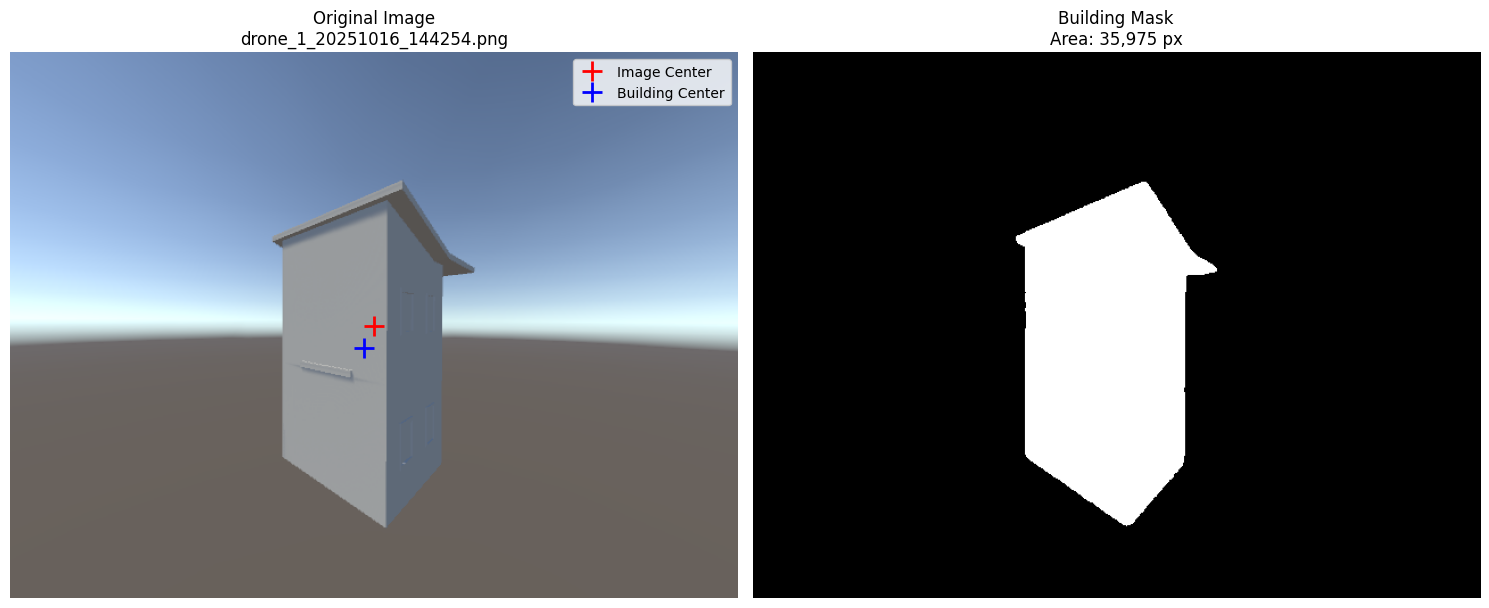


📸 Processing image 10/30: drone_2_20251016_144236.png
✅ Building detected!
   Area: 33,985 pixels (11.1% of image)
   Center offset: (-17, 29)
   Processing time: 2.29 seconds


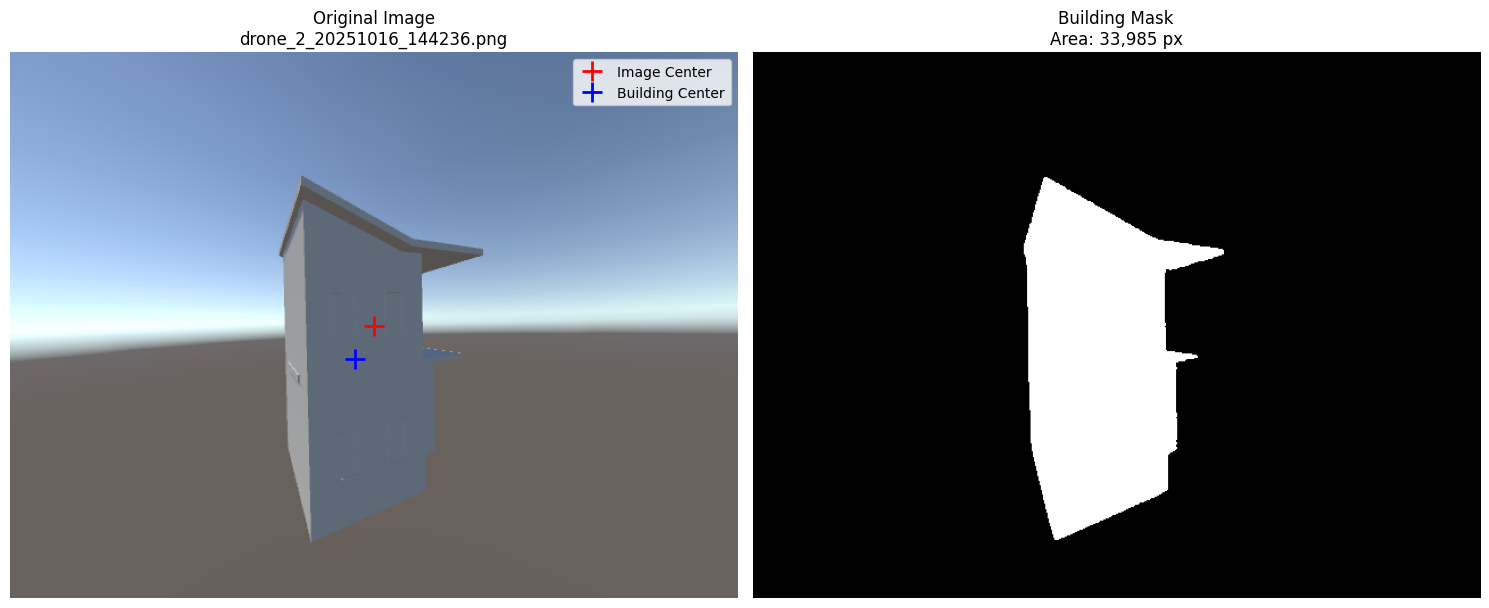


📸 Processing image 11/30: drone_2_20251016_144238.png
✅ Building detected!
   Area: 35,107 pixels (11.4% of image)
   Center offset: (-16, 32)
   Processing time: 2.27 seconds


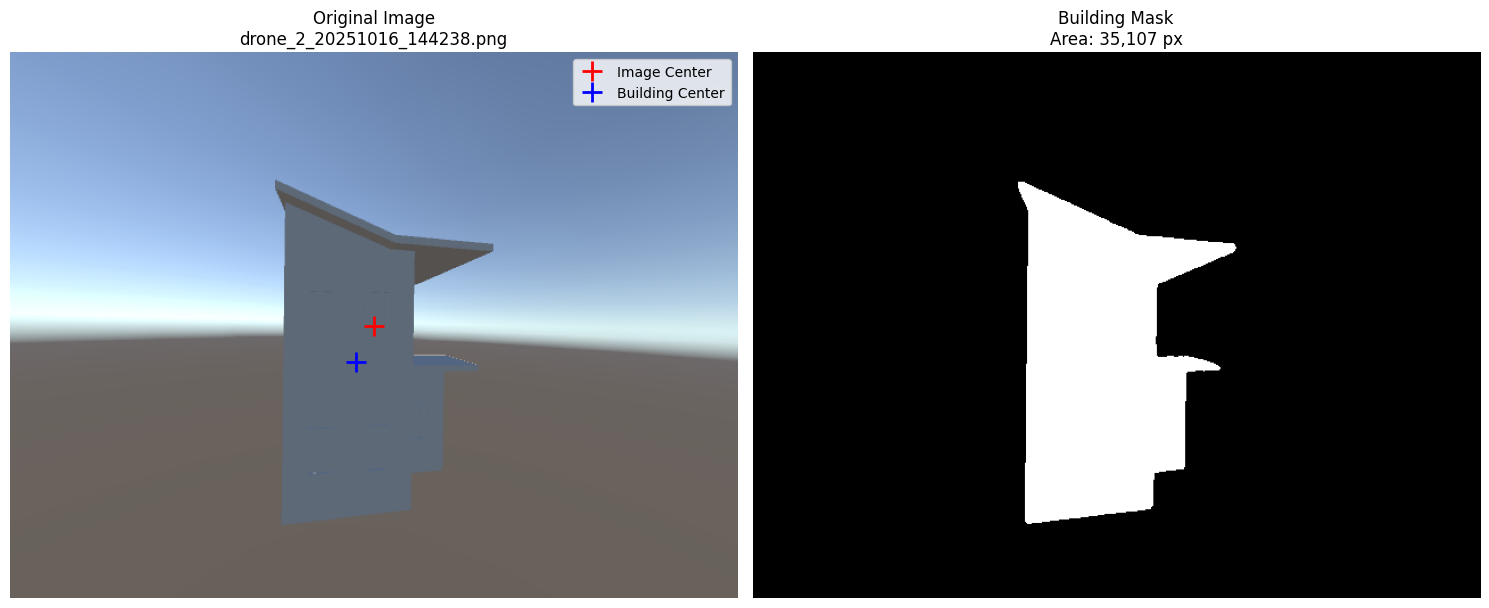


📸 Processing image 12/30: drone_2_20251016_144244.png
✅ Building detected!
   Area: 26,487 pixels (8.6% of image)
   Center offset: (13, 22)
   Processing time: 2.32 seconds


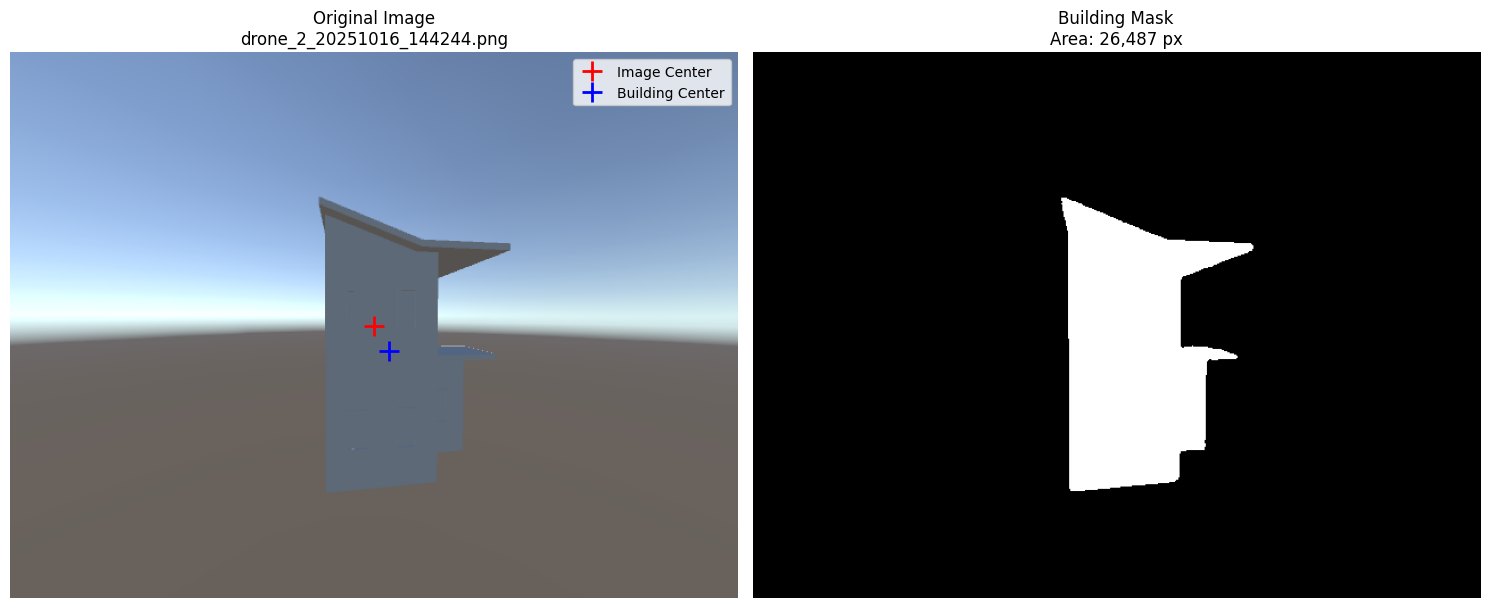


📸 Processing image 13/30: drone_2_20251016_144246.png
✅ Building detected!
   Area: 34,168 pixels (11.1% of image)
   Center offset: (26, 34)
   Processing time: 2.29 seconds


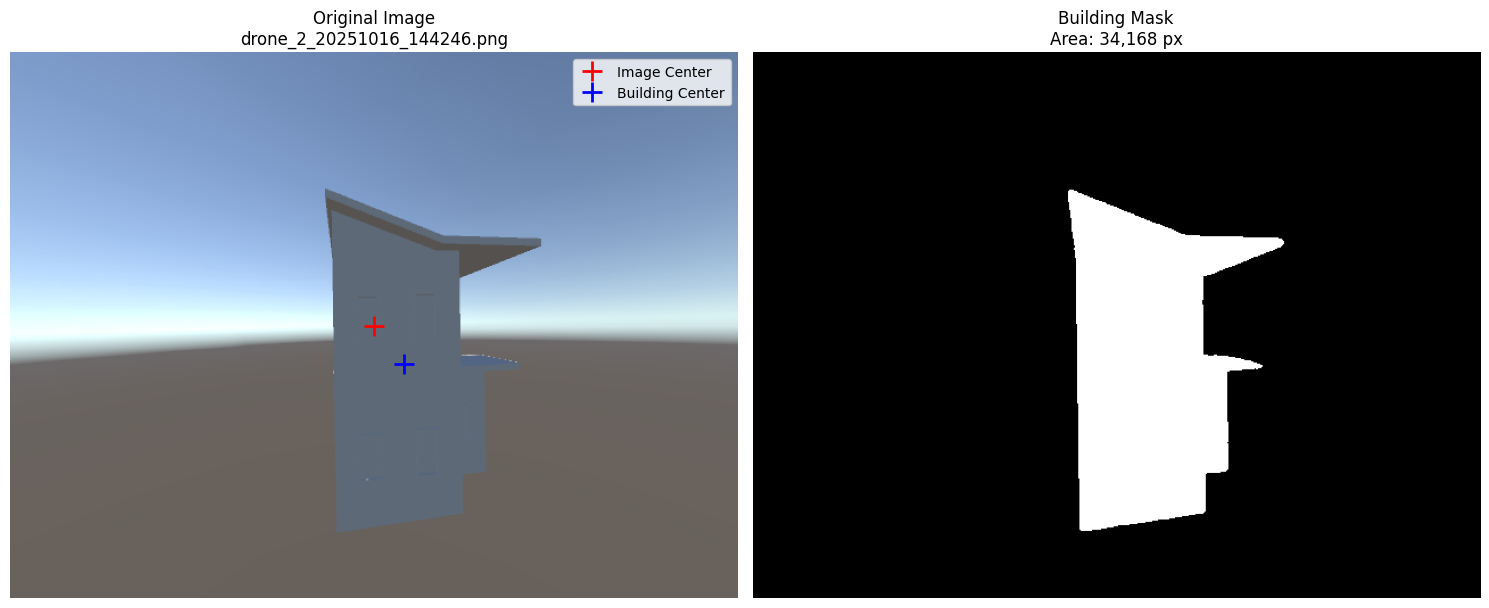


📸 Processing image 14/30: drone_2_20251016_144248.png
✅ Building detected!
   Area: 40,977 pixels (13.3% of image)
   Center offset: (9, 47)
   Processing time: 2.27 seconds


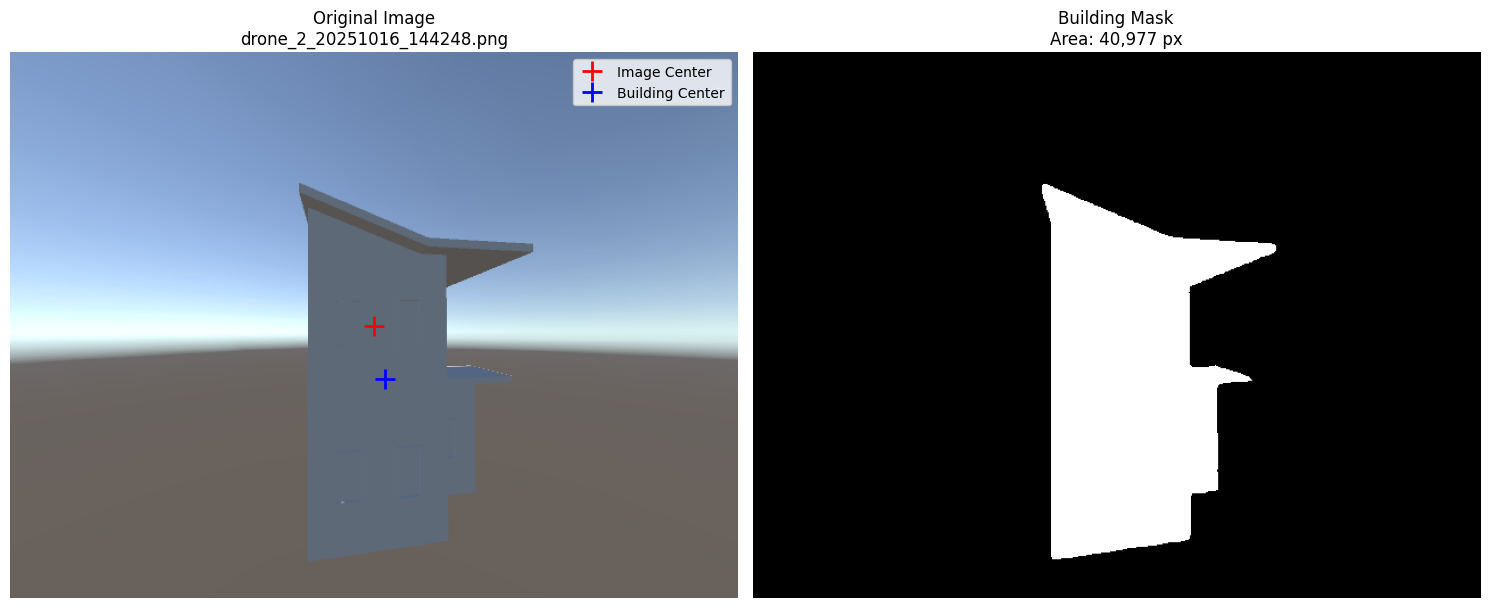


📸 Processing image 15/30: drone_2_20251016_144252.png
✅ Building detected!
   Area: 30,227 pixels (9.8% of image)
   Center offset: (5, 26)
   Processing time: 2.25 seconds


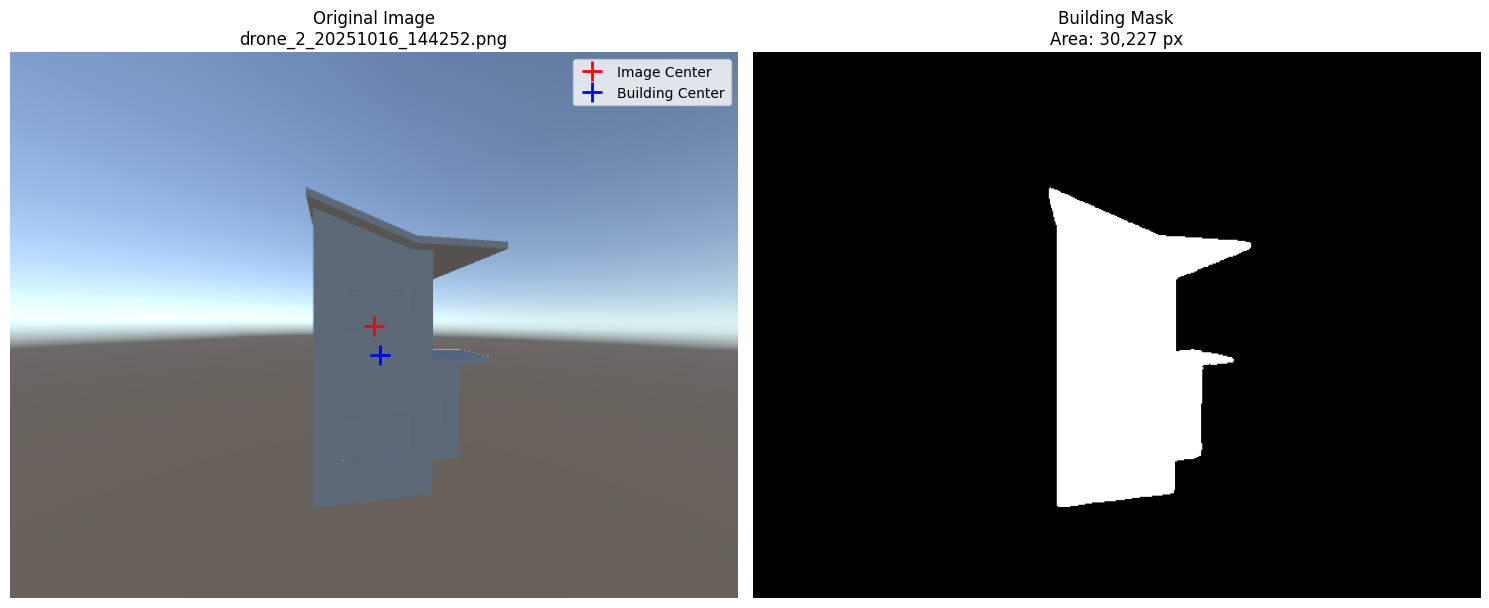


📸 Processing image 16/30: drone_3_20251016_144230.png
✅ Building detected!
   Area: 117,536 pixels (38.3% of image)
   Center offset: (-20, -5)
   Processing time: 2.20 seconds


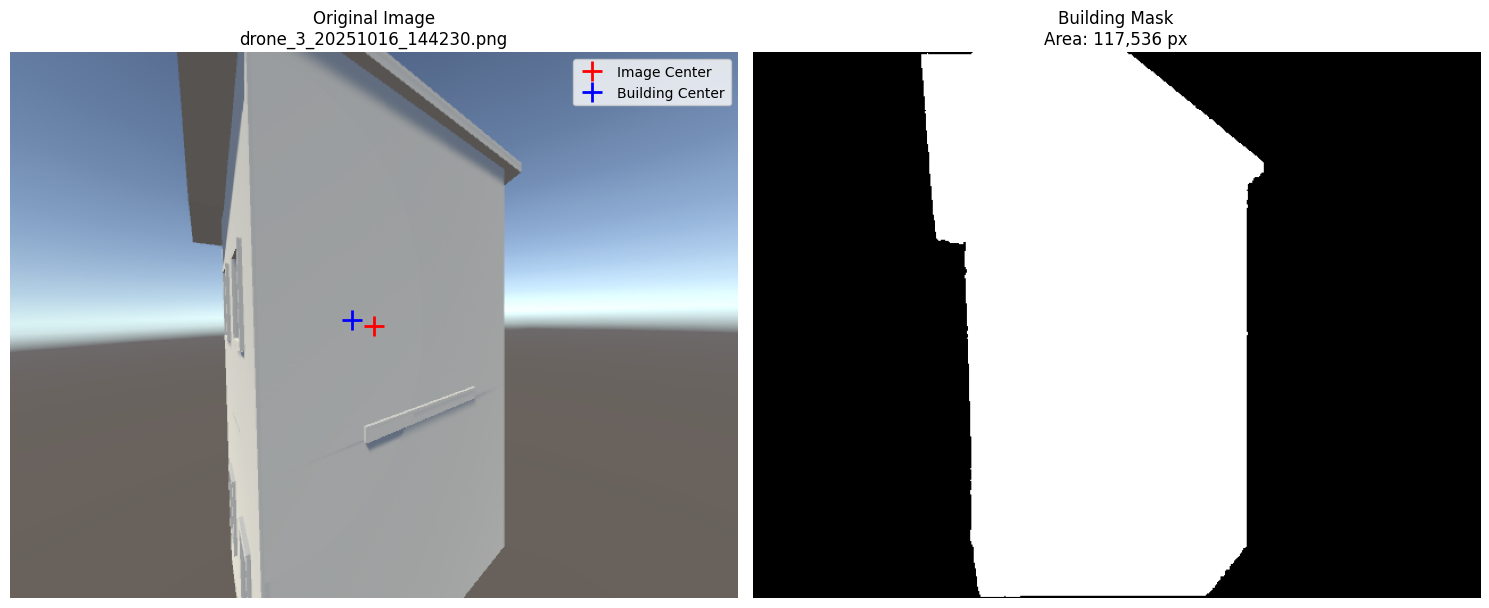


📸 Processing image 17/30: drone_3_20251016_144246.png
✅ Building detected!
   Area: 53,914 pixels (17.6% of image)
   Center offset: (-23, 48)
   Processing time: 2.35 seconds


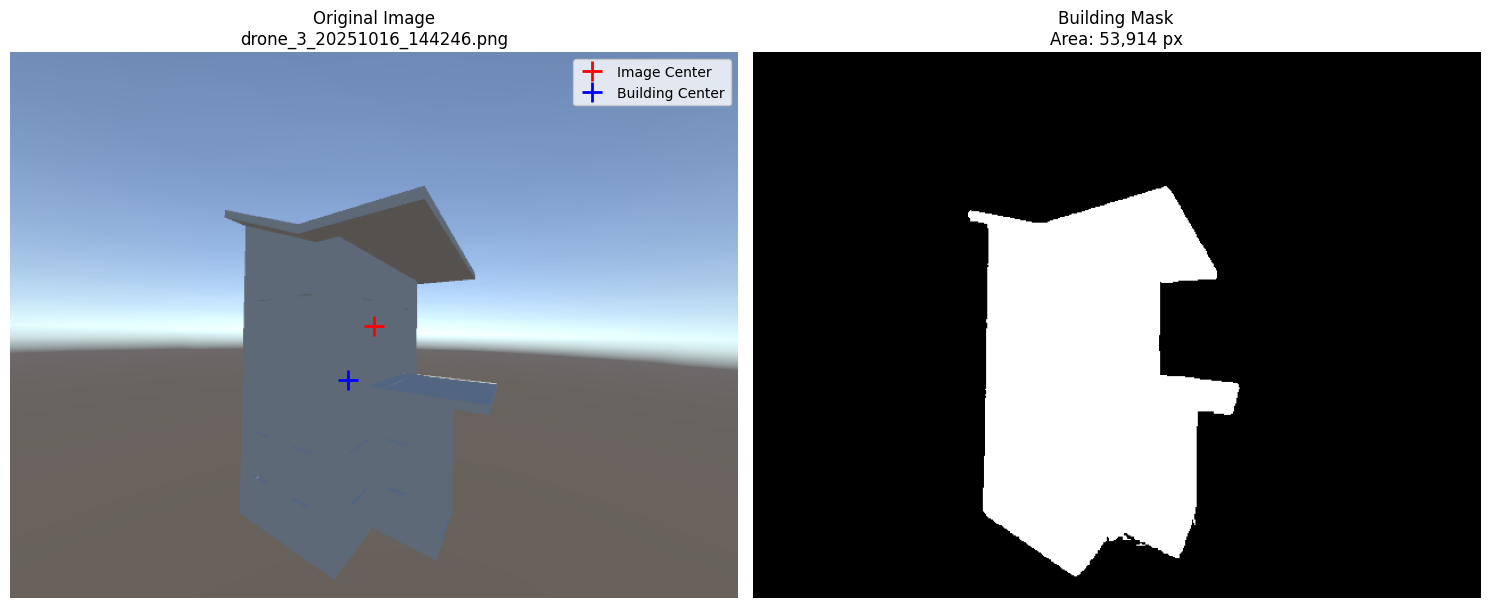


📸 Processing image 18/30: drone_3_20251016_144254.png
✅ Building detected!
   Area: 44,844 pixels (14.6% of image)
   Center offset: (-3, 45)
   Processing time: 2.27 seconds


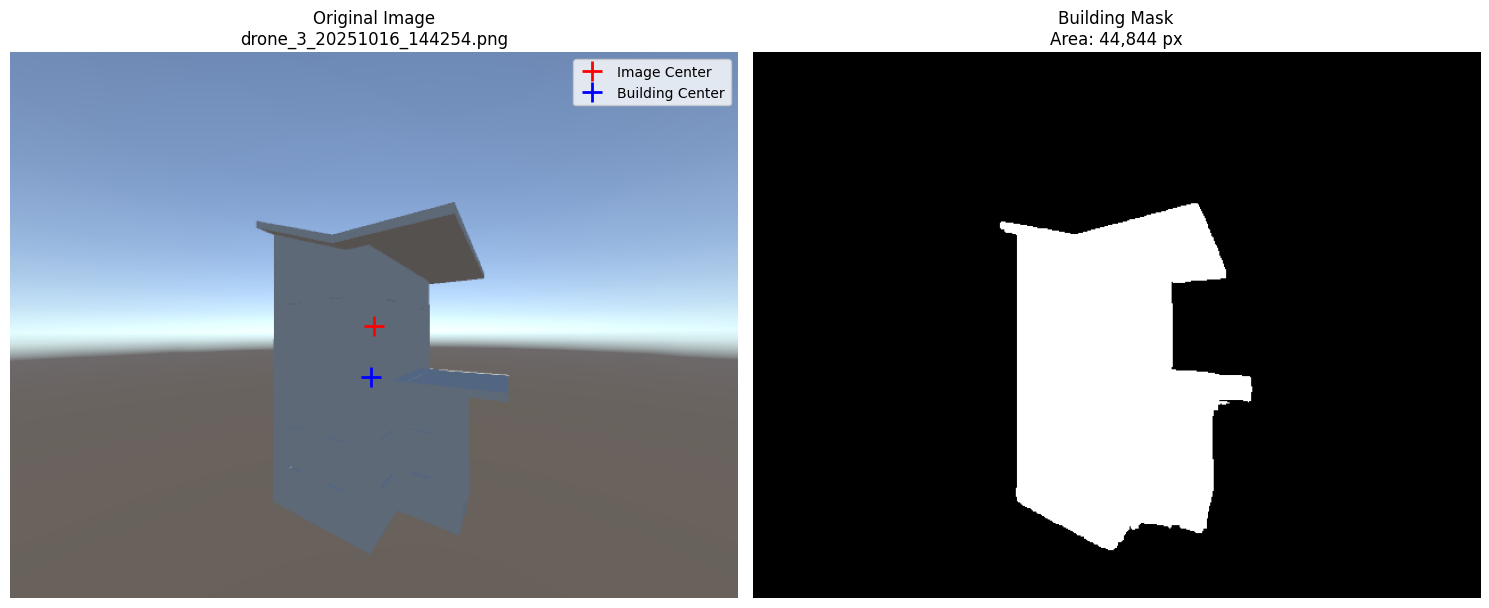


📸 Processing image 19/30: drone_5_20251016_144224.png
✅ Building detected!
   Area: 36,022 pixels (11.7% of image)
   Center offset: (7, 72)
   Processing time: 2.38 seconds


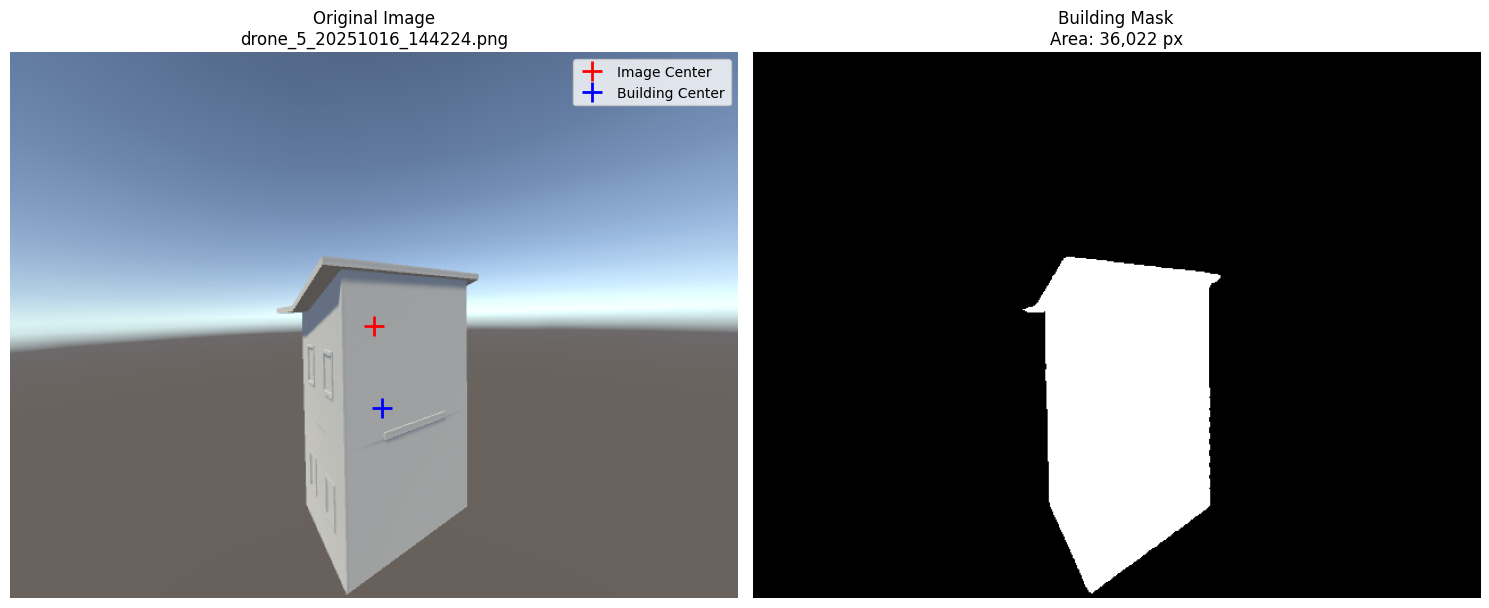


📸 Processing image 20/30: drone_5_20251016_144226.png
✅ Building detected!
   Area: 73,697 pixels (24.0% of image)
   Center offset: (-4, 27)
   Processing time: 2.28 seconds


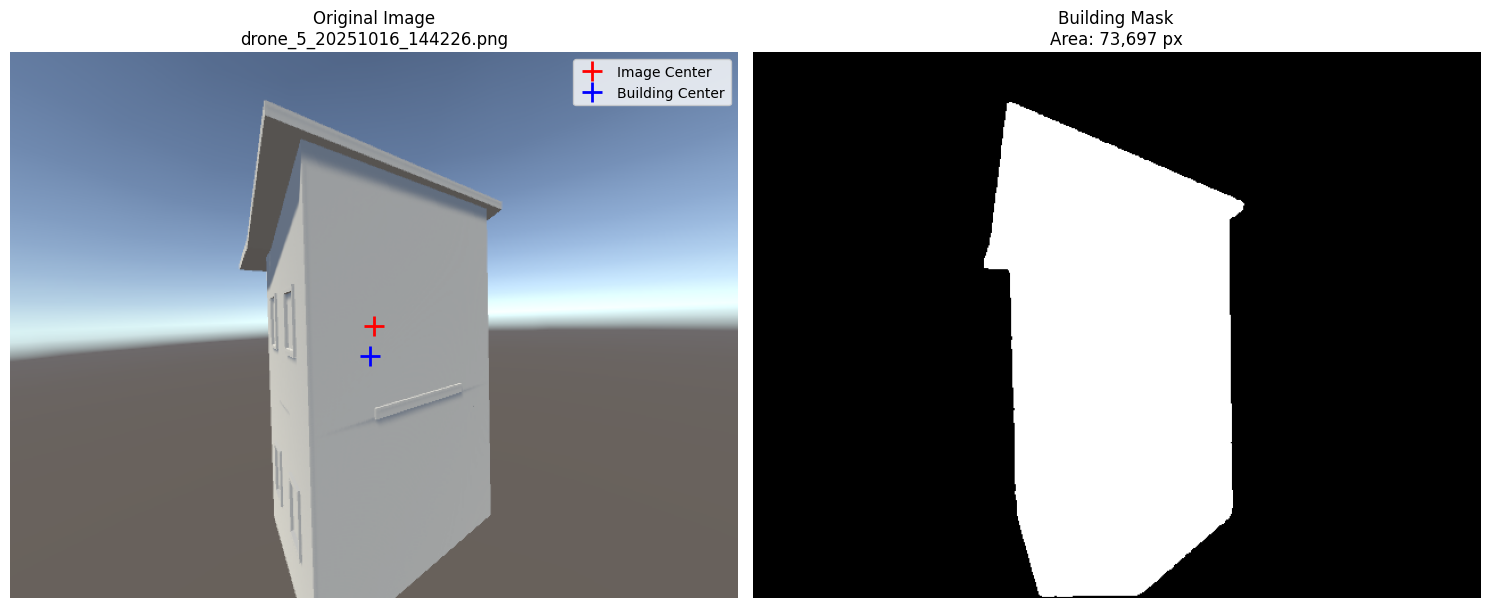


📸 Processing image 21/30: drone_5_20251016_144236.png
✅ Building detected!
   Area: 304,639 pixels (99.2% of image)
   Center offset: (-1, -1)
   Processing time: 2.96 seconds


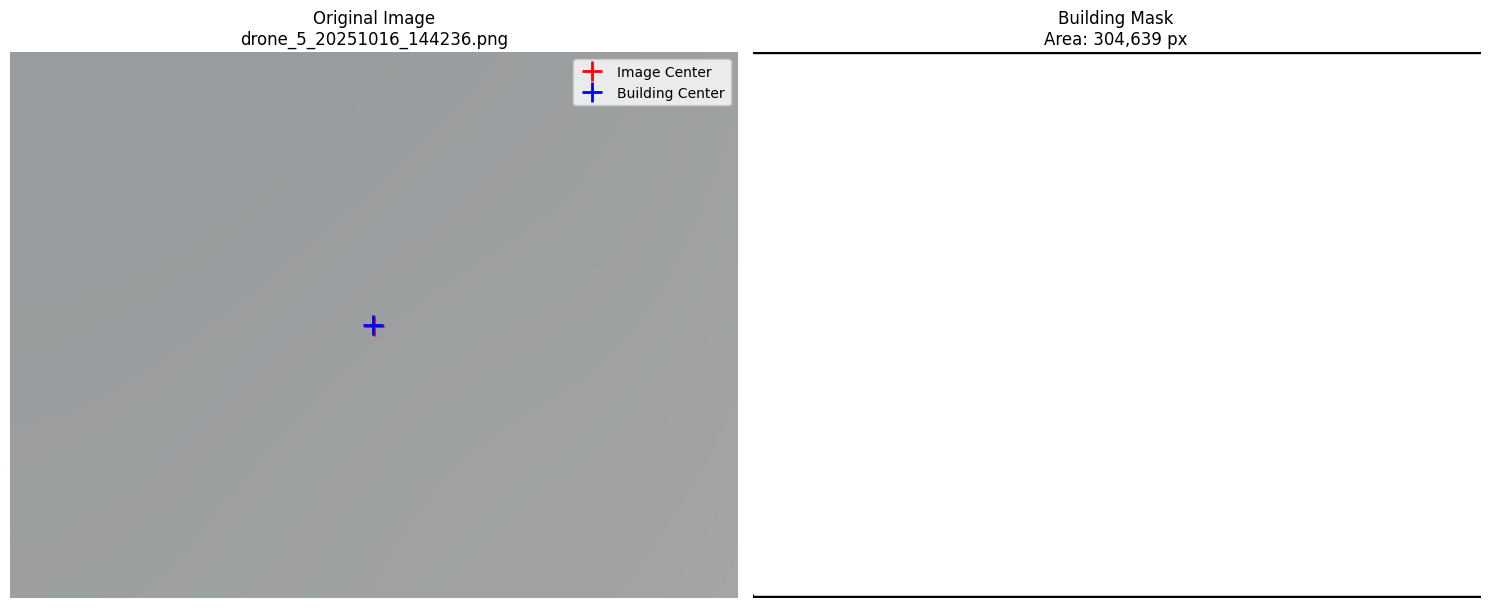


📸 Processing image 22/30: drone_5_20251016_144252.png
✅ Building detected!
   Area: 63,415 pixels (20.6% of image)
   Center offset: (61, 52)
   Processing time: 2.28 seconds


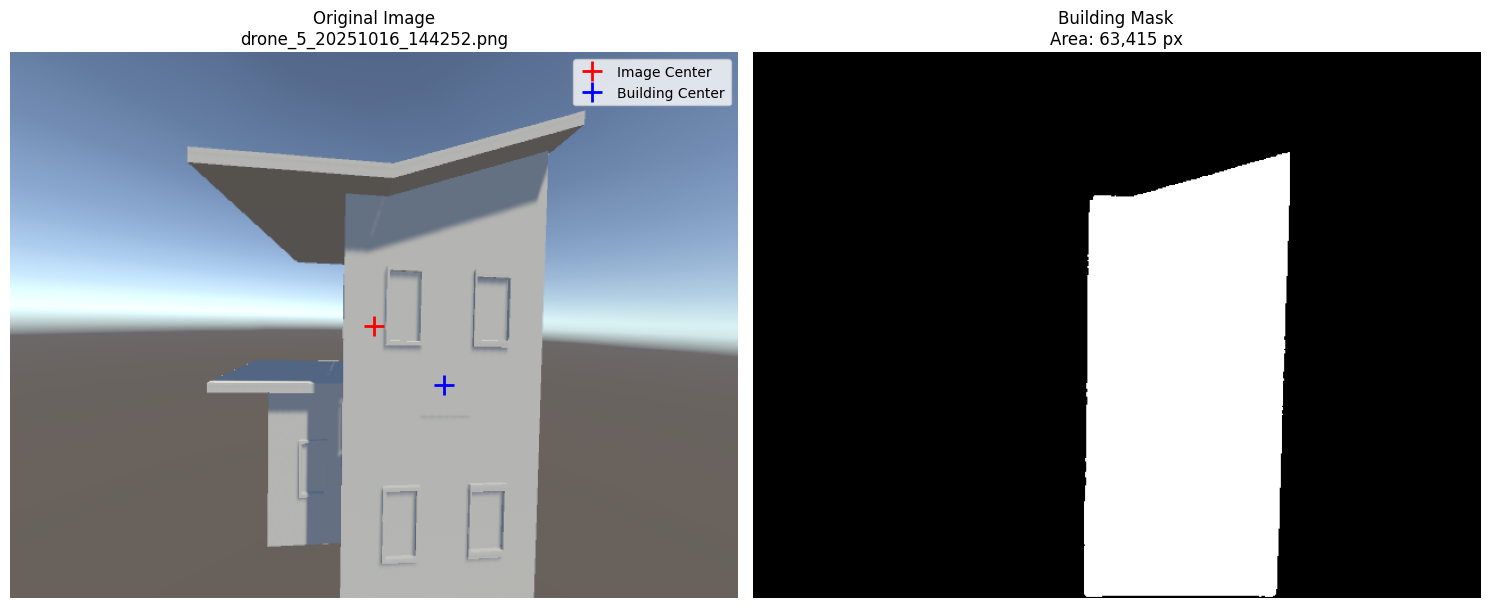


📸 Processing image 23/30: drone_6_20251016_144234.png
✅ Building detected!
   Area: 55,628 pixels (18.1% of image)
   Center offset: (21, 59)
   Processing time: 2.30 seconds


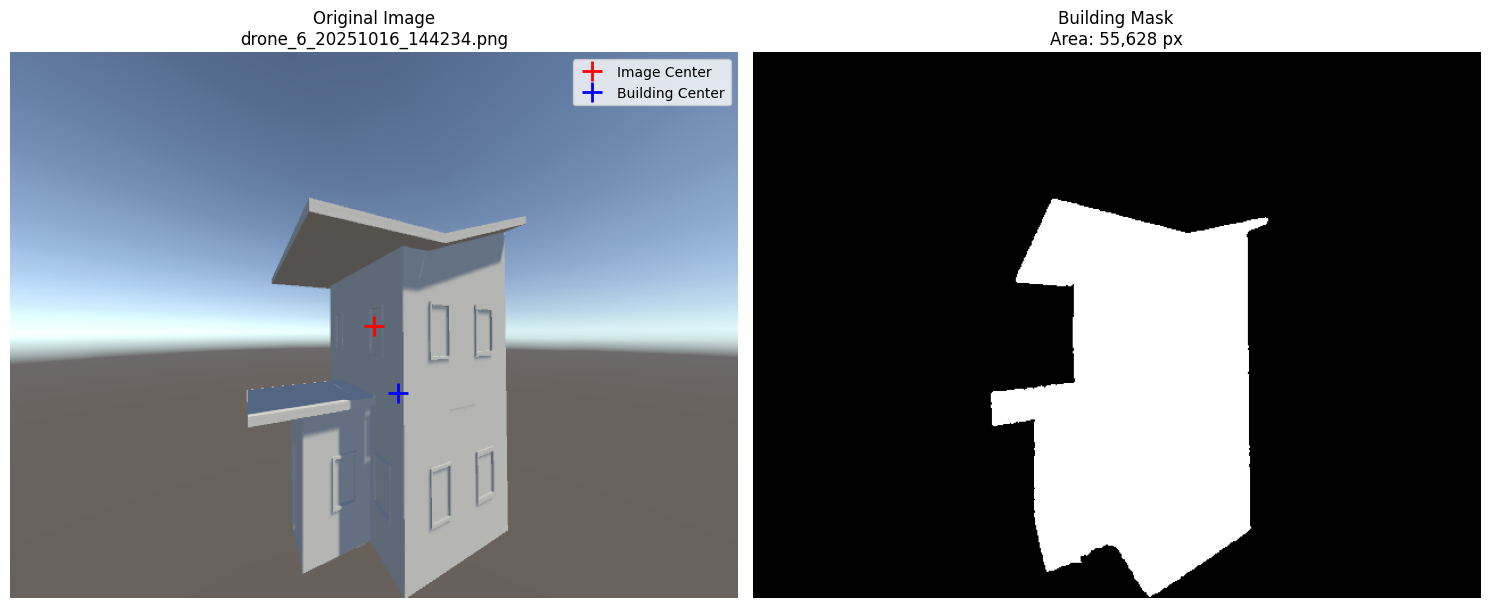


📸 Processing image 24/30: drone_6_20251016_144240.png
✅ Building detected!
   Area: 24,395 pixels (7.9% of image)
   Center offset: (10, 36)
   Processing time: 2.31 seconds


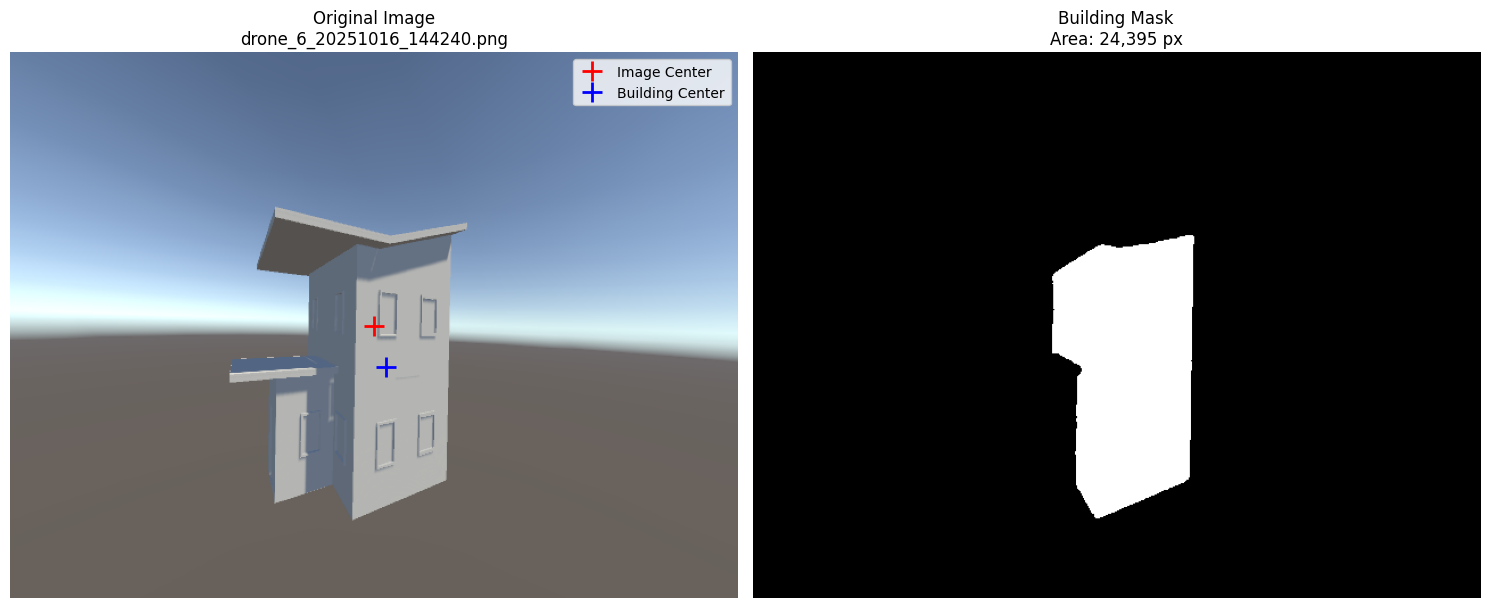


📸 Processing image 25/30: drone_7_20251016_144228.png
✅ Building detected!
   Area: 19,766 pixels (6.4% of image)
   Center offset: (13, 2)
   Processing time: 2.36 seconds


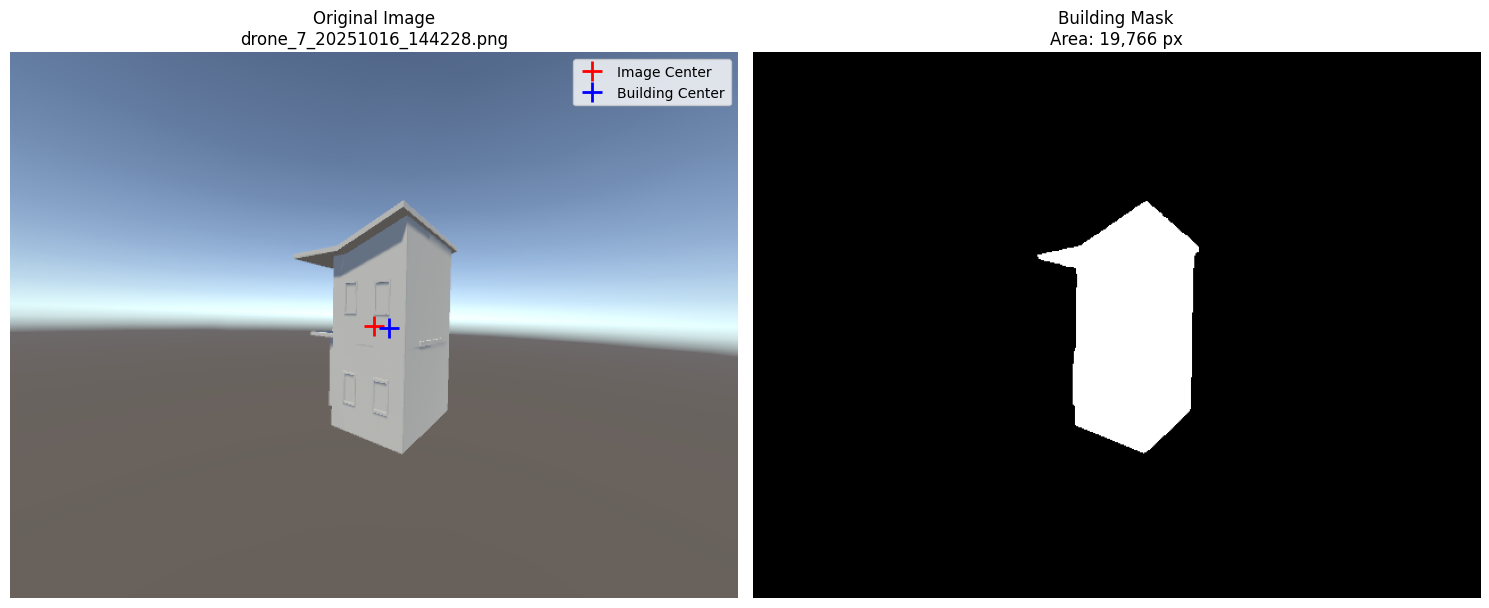


📸 Processing image 26/30: drone_7_20251016_144240.png
✅ Building detected!
   Area: 28,764 pixels (9.4% of image)
   Center offset: (-24, 22)
   Processing time: 2.40 seconds


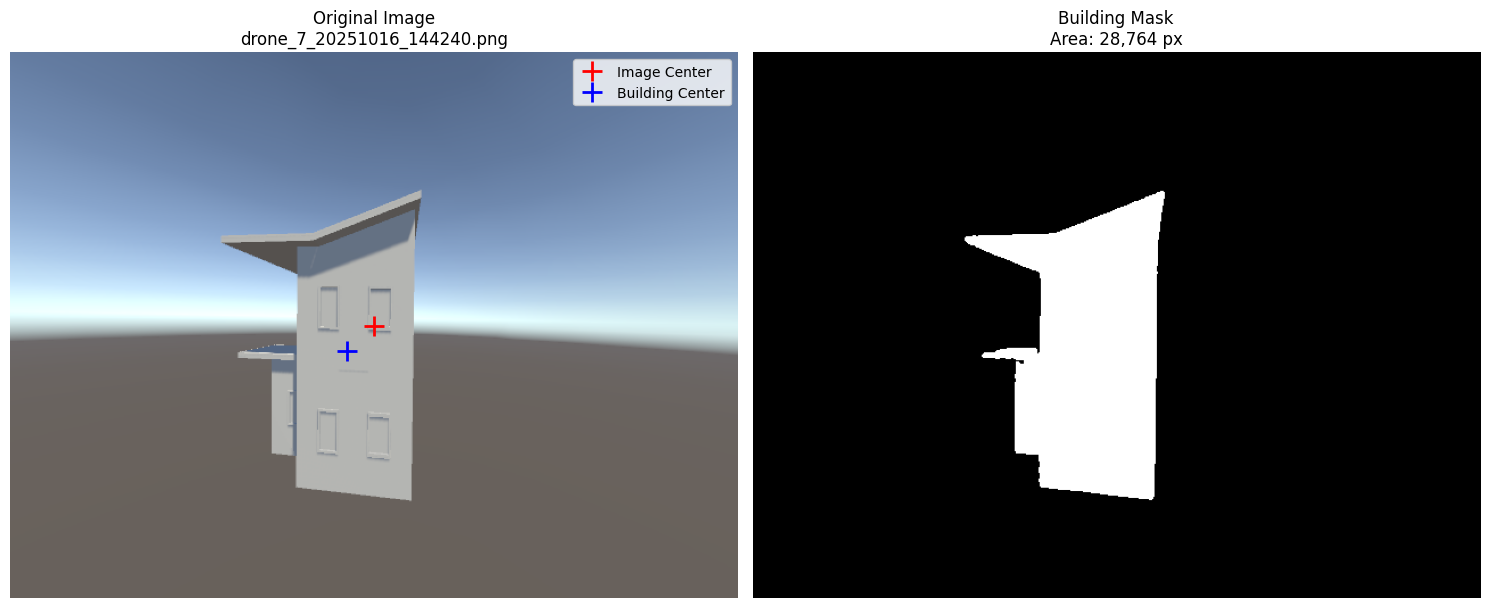


📸 Processing image 27/30: drone_7_20251016_144252.png
✅ Building detected!
   Area: 36,594 pixels (11.9% of image)
   Center offset: (-14, 37)
   Processing time: 2.38 seconds


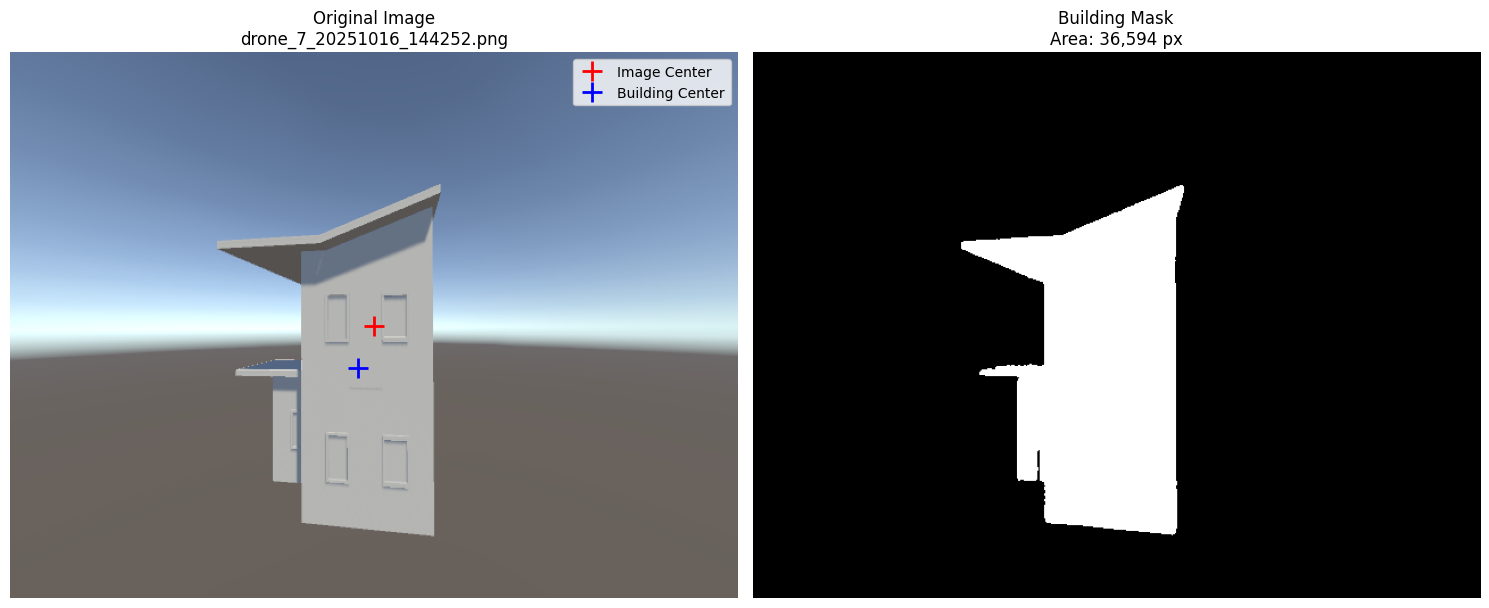


📸 Processing image 28/30: drone_8_20251016_144238.png
✅ Building detected!
   Area: 37,132 pixels (12.1% of image)
   Center offset: (18, 21)
   Processing time: 2.32 seconds


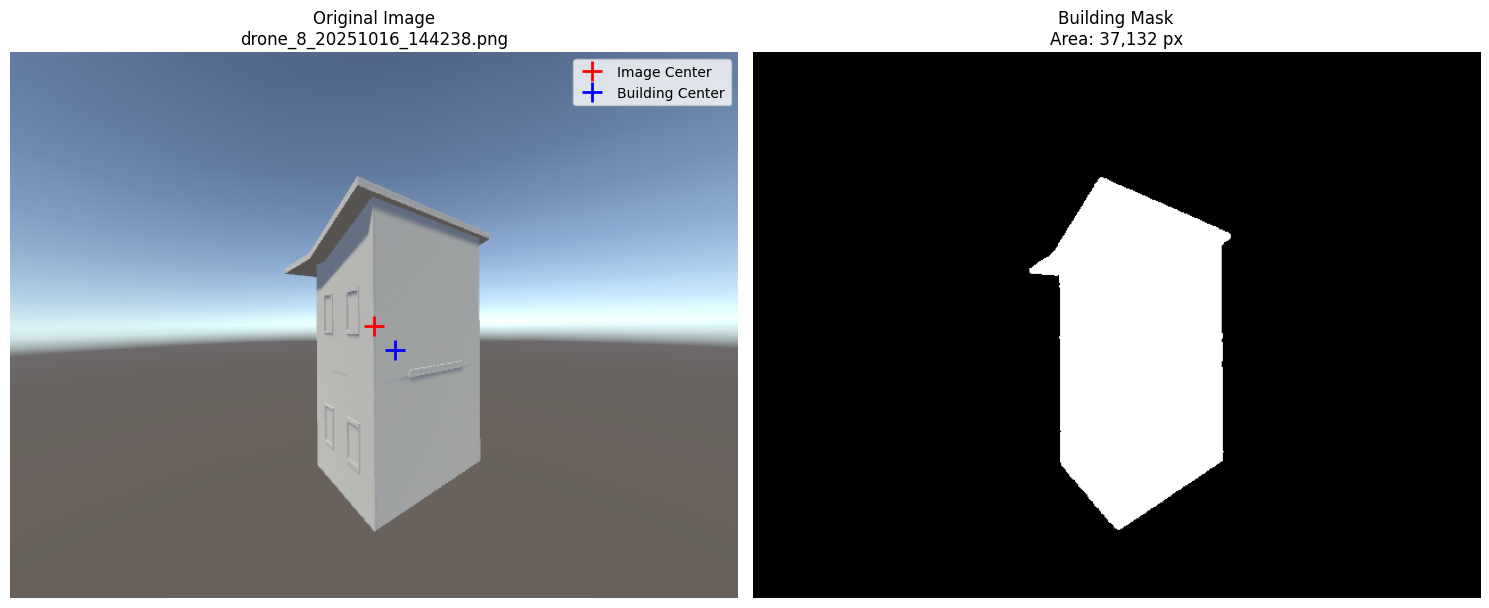


📸 Processing image 29/30: drone_8_20251016_144244.png
✅ Building detected!
   Area: 42,924 pixels (14.0% of image)
   Center offset: (18, 33)
   Processing time: 2.30 seconds


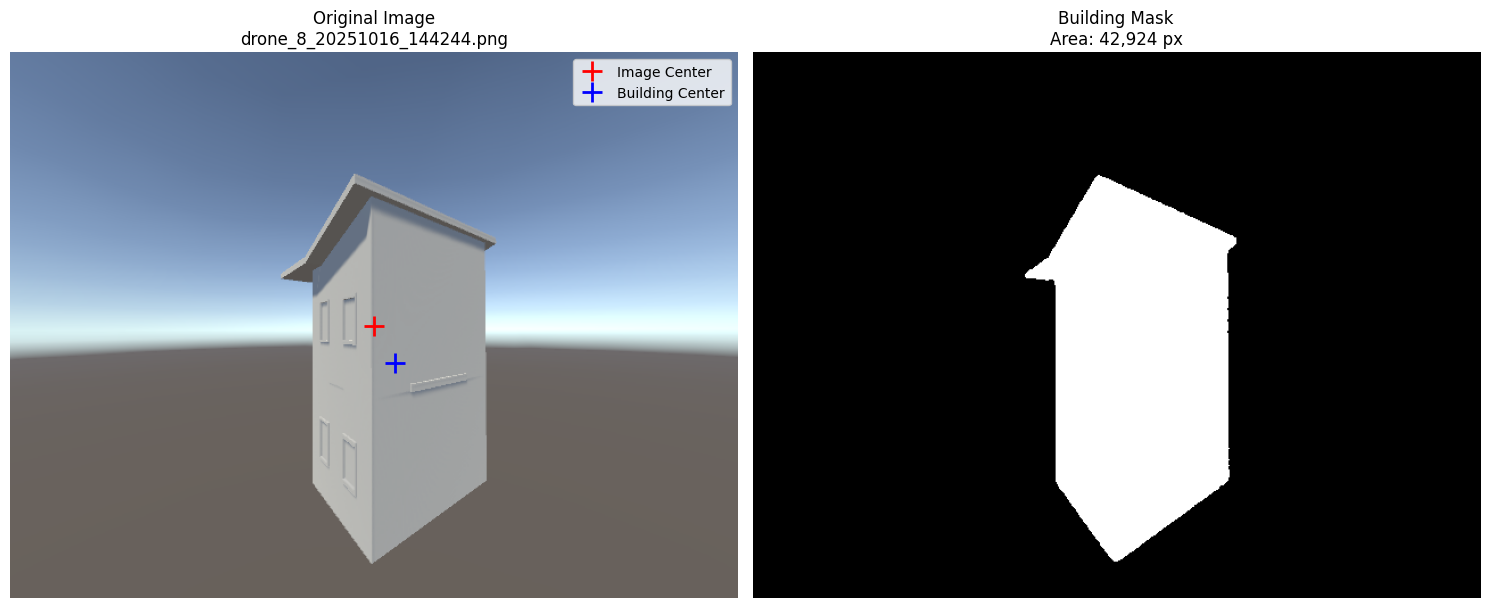


📸 Processing image 30/30: drone_8_20251016_144254.png
✅ Building detected!
   Area: 38,003 pixels (12.4% of image)
   Center offset: (18, 23)
   Processing time: 2.46 seconds


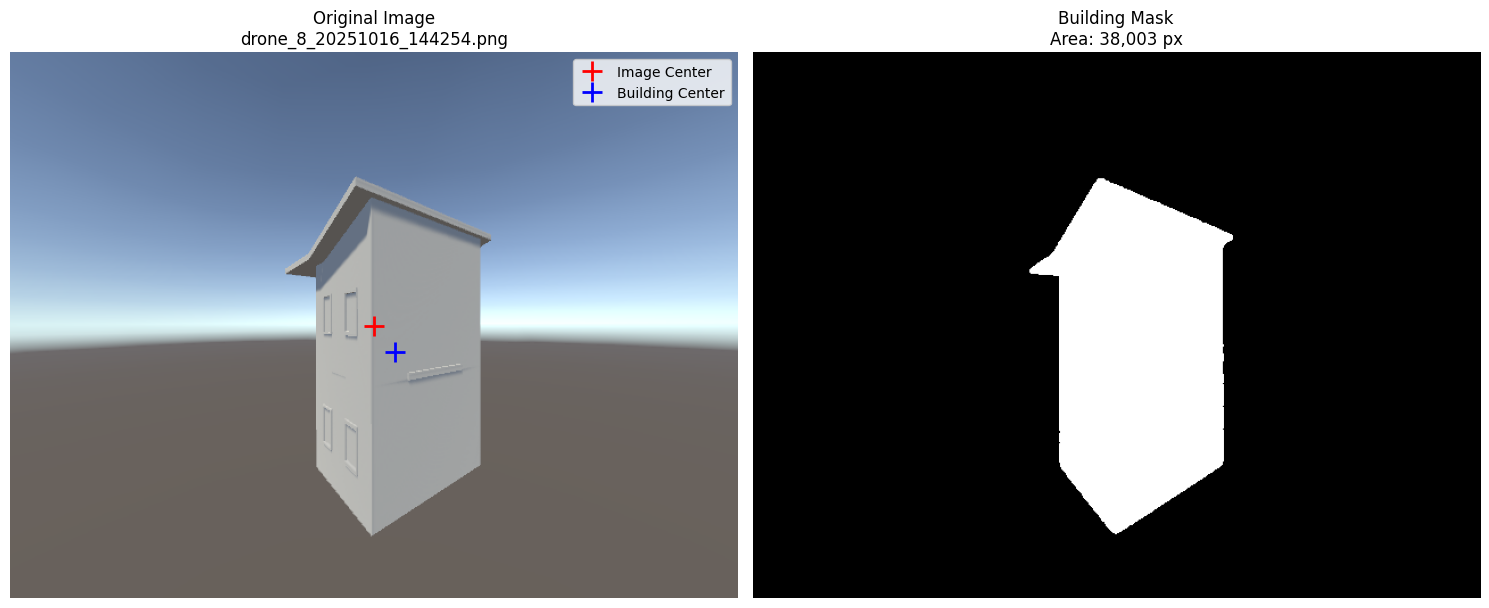


📊 BATCH PROCESSING RESULTS
🖼️  Total images processed: 30/30
✅ Successful building detections: 30
📈 Success rate: 100.0%
⏱️  Total processing time: 74.16 seconds
📊 Average time per image: 2.34 seconds
⚡ Fastest image: 2.20 seconds
🐌 Slowest image: 2.96 seconds
🏎️  Images per second: 0.43


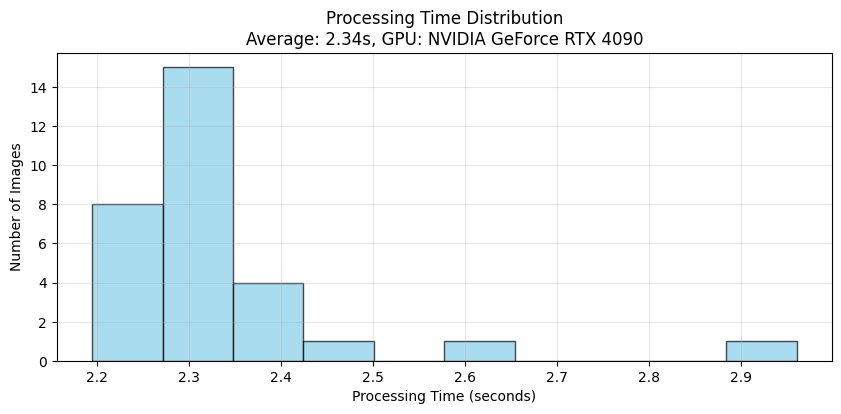

In [11]:
# Add this as a new cell
## 6. Batch Process All Drone Images with GPU Acceleration

import os
import glob
import time
from pathlib import Path

def process_all_drone_images(images_folder="../../DroneImages", min_area=7500):
    """
    Process all PNG images in the DroneImages folder with GPU-accelerated SAM.
    Returns timing statistics and displays results for each image.
    """
    
    # Find all PNG images
    image_pattern = os.path.join(images_folder, "*.png")
    image_paths = glob.glob(image_pattern)

    # pick upto 30 random images from the folder. if less than 30 pick all images
    if len(image_paths) > 30:
        image_paths = np.random.choice(image_paths, 30, replace=False).tolist()
    
    if not image_paths:
        print(f"❌ No PNG images found in {images_folder}")
        return
    
    print(f"🔍 Found {len(image_paths)} images to process")
    print(f"📂 Processing images from: {images_folder}")
    print(f"🚀 Using GPU acceleration: {device}")
    print(f"📏 Minimum building area: {min_area:,} pixels")
    print("-" * 60)
    
    # Initialize timing
    total_start_time = time.time()
    processing_times = []
    successful_detections = 0
    
    # Process each image
    for i, image_path in enumerate(sorted(image_paths)):
        print(f"\n📸 Processing image {i+1}/{len(image_paths)}: {os.path.basename(image_path)}")
        
        # Start timing for this image
        image_start_time = time.time()
        
        try:
            # Load image
            image = cv2.imread(image_path)
            if image is None:
                print(f"❌ Failed to load {image_path}")
                continue
                
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            height, width, _ = image.shape
            
            # Generate masks with GPU acceleration
            masks = mask_generator.generate(image_rgb)
            
            # Find center building segment
            center_x = width // 2
            center_y = height // 2
            
            # Find best center segment
            center_segments = []
            for j, mask_info in enumerate(masks):
                mask = mask_info['segmentation']
                area = mask_info['area']
                
                if point_in_mask(mask, center_x, center_y) and area >= min_area:
                    center_segments.append((j, mask_info))
            
            # Calculate processing time
            image_end_time = time.time()
            processing_time = image_end_time - image_start_time
            processing_times.append(processing_time)
            
            # Display results
            if center_segments:
                # Get best segment
                best_segment = max(center_segments, 
                                 key=lambda x: x[1]['stability_score'] * min(x[1]['area']/10000, 10))
                
                segment_idx, segment_info = best_segment
                center_mask = segment_info['segmentation']
                successful_detections += 1
                
                # Calculate building center
                building_pixels = np.where(center_mask)
                building_center_y = int(np.mean(building_pixels[0]))
                building_center_x = int(np.mean(building_pixels[1]))
                
                print(f"✅ Building detected!")
                print(f"   Area: {segment_info['area']:,} pixels ({segment_info['area']/(height*width)*100:.1f}% of image)")
                print(f"   Center offset: ({building_center_x - center_x}, {building_center_y - center_y})")
                print(f"   Processing time: {processing_time:.2f} seconds")
                
                # Plot results
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                
                # Original image
                axes[0].imshow(image_rgb)
                axes[0].plot(center_x, center_y, 'r+', markersize=15, markeredgewidth=2, label='Image Center')
                axes[0].plot(building_center_x, building_center_y, 'b+', markersize=15, markeredgewidth=2, label='Building Center')
                axes[0].set_title(f"Original Image\n{os.path.basename(image_path)}", fontsize=12)
                axes[0].legend()
                axes[0].axis('off')
                
                # Segmentation mask
                axes[1].imshow(center_mask, cmap='gray')
                axes[1].set_title(f"Building Mask\nArea: {segment_info['area']:,} px", fontsize=12)
                axes[1].axis('off')
                
                plt.tight_layout()
                plt.show()
                
            else:
                print(f"❌ No suitable building segment found")
                print(f"   Found {len(masks)} total segments")
                print(f"   Processing time: {processing_time:.2f} seconds")
                
                # Show image with all segments
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                
                # Original image
                axes[0].imshow(image_rgb)
                axes[0].plot(center_x, center_y, 'r+', markersize=15, markeredgewidth=2)
                axes[0].set_title(f"Original Image\n{os.path.basename(image_path)}", fontsize=12)
                axes[0].axis('off')
                
                # All segments
                axes[1].imshow(image_rgb)
                show_anns(masks, axes[1])
                axes[1].plot(center_x, center_y, 'r+', markersize=15, markeredgewidth=2)
                axes[1].set_title(f"All Segments\n{len(masks)} found", fontsize=12)
                axes[1].axis('off')
                
                plt.tight_layout()
                plt.show()
                
        except Exception as e:
            print(f"❌ Error processing {image_path}: {str(e)}")
            continue
    
    # Calculate final statistics
    total_end_time = time.time()
    total_time = total_end_time - total_start_time
    
    print("\n" + "="*60)
    print("📊 BATCH PROCESSING RESULTS")
    print("="*60)
    print(f"🖼️  Total images processed: {len(processing_times)}/{len(image_paths)}")
    print(f"✅ Successful building detections: {successful_detections}")
    print(f"📈 Success rate: {(successful_detections/max(len(processing_times),1))*100:.1f}%")
    print(f"⏱️  Total processing time: {total_time:.2f} seconds")
    
    if processing_times:
        avg_time = sum(processing_times) / len(processing_times)
        min_time = min(processing_times)
        max_time = max(processing_times)
        
        print(f"📊 Average time per image: {avg_time:.2f} seconds")
        print(f"⚡ Fastest image: {min_time:.2f} seconds")
        print(f"🐌 Slowest image: {max_time:.2f} seconds")
        print(f"🏎️  Images per second: {1/avg_time:.2f}")
        
        # Show timing distribution
        plt.figure(figsize=(10, 4))
        plt.hist(processing_times, bins=min(10, len(processing_times)), alpha=0.7, color='skyblue', edgecolor='black')
        plt.xlabel('Processing Time (seconds)')
        plt.ylabel('Number of Images')
        plt.title(f'Processing Time Distribution\nAverage: {avg_time:.2f}s, GPU: {torch.cuda.get_device_name(0)}')
        plt.grid(True, alpha=0.3)
        plt.show()
    
    return {
        'total_images': len(image_paths),
        'processed_images': len(processing_times),
        'successful_detections': successful_detections,
        'total_time': total_time,
        'processing_times': processing_times,
        'average_time_per_image': sum(processing_times) / len(processing_times) if processing_times else 0
    }

# Run the batch processing
print("🚀 Starting batch processing of all drone images...")
results = process_all_drone_images()